# Milestone 1 - EDA and Preprocessing data 

***Important note*** - This is merely a template. you are recommended to create your own notebook from scratch.

> Make sure to include markdown-based text commenting and explaining each step you perform.

# 1 - Extraction

### Importing libraries and loading dataset

In [1]:
!pip install requests


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: D:\TensorFlow\Python 3.10\python.exe -m pip install --upgrade pip


In [2]:
pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import requests
from bs4 import BeautifulSoup

In [4]:
plt.style.use('ggplot')
pd.set_option("display.max_columns", None)

In [5]:
fintech_df = pd.read_csv('./Dataset/fintech_data_18_52_11870.csv', index_col=0)

# 2- EDA

In [6]:
fintech_df.shape

(27030, 23)

In [7]:
fintech_df[~fintech_df['Emp Title'].isnull() & fintech_df['Emp Title'].str.lower().str.startswith('7')]

,Emp Title,Emp Length,Home Ownership,Annual Inc,Annual Inc Joint,Verification Status,Zip Code,Addr State,Avg Cur Bal,Tot Cur Bal,Loan Id,Loan Status,Loan Amount,State,Funded Amount,Term,Int Rate,Grade,Issue Date,Pymnt Plan,Type,Purpose,Description
Customer Id,,,,,,,,,,,,,,,,,,,,,,,


Check if there are any empty columns

In [8]:
fintech_df[fintech_df.isnull().all(axis=1)]

,Emp Title,Emp Length,Home Ownership,Annual Inc,Annual Inc Joint,Verification Status,Zip Code,Addr State,Avg Cur Bal,Tot Cur Bal,Loan Id,Loan Status,Loan Amount,State,Funded Amount,Term,Int Rate,Grade,Issue Date,Pymnt Plan,Type,Purpose,Description
Customer Id,,,,,,,,,,,,,,,,,,,,,,,


In [9]:
fintech_df.isnull().sum()

Emp Title               2320
Emp Length              1809
Home Ownership             0
Annual Inc                 0
Annual Inc Joint       25136
Verification Status        0
Zip Code                   0
Addr State                 0
Avg Cur Bal                0
Tot Cur Bal                0
Loan Id                    0
Loan Status                0
Loan Amount                0
State                      0
Funded Amount              0
Term                       0
Int Rate                1193
Grade                      0
Issue Date                 0
Pymnt Plan                 0
Type                       0
Purpose                    0
Description              256
dtype: int64

In [10]:
fintech_df.isnull().mean() * 100

Emp Title               8.583056
Emp Length              6.692564
Home Ownership          0.000000
Annual Inc              0.000000
Annual Inc Joint       92.992971
Verification Status     0.000000
Zip Code                0.000000
Addr State              0.000000
Avg Cur Bal             0.000000
Tot Cur Bal             0.000000
Loan Id                 0.000000
Loan Status             0.000000
Loan Amount             0.000000
State                   0.000000
Funded Amount           0.000000
Term                    0.000000
Int Rate                4.413615
Grade                   0.000000
Issue Date              0.000000
Pymnt Plan              0.000000
Type                    0.000000
Purpose                 0.000000
Description             0.947096
dtype: float64

In [11]:
fintech_df.columns

Index(['Emp Title', 'Emp Length', 'Home Ownership', 'Annual Inc',
       'Annual Inc Joint', 'Verification Status', 'Zip Code', 'Addr State',
       'Avg Cur Bal', 'Tot Cur Bal', 'Loan Id', 'Loan Status', 'Loan Amount',
       'State', 'Funded Amount', 'Term', 'Int Rate', 'Grade', 'Issue Date',
       'Pymnt Plan', 'Type', 'Purpose', 'Description'],
      dtype='object')

In [12]:
fintech_df.dtypes

Emp Title               object
Emp Length              object
Home Ownership          object
Annual Inc             float64
Annual Inc Joint       float64
Verification Status     object
Zip Code                object
Addr State              object
Avg Cur Bal            float64
Tot Cur Bal            float64
Loan Id                  int64
Loan Status             object
Loan Amount            float64
State                   object
Funded Amount          float64
Term                    object
Int Rate               float64
Grade                    int64
Issue Date              object
Pymnt Plan                bool
Type                    object
Purpose                 object
Description             object
dtype: object

### Taking a look at the first and last 5 rows in the dataset

In [13]:
fintech_df.head()

,Emp Title,Emp Length,Home Ownership,Annual Inc,Annual Inc Joint,Verification Status,Zip Code,Addr State,Avg Cur Bal,Tot Cur Bal,Loan Id,Loan Status,Loan Amount,State,Funded Amount,Term,Int Rate,Grade,Issue Date,Pymnt Plan,Type,Purpose,Description
Customer Id,,,,,,,,,,,,,,,,,,,,,,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,Store Manager,2 years,MORTGAGE,77500.0,NaN,Source Verified,550xx,MN,50693.0,354848.0,146317,Current,15000.0,MN,15000.0,36 months,0.0667,3,18 October 2018,False,Individual,debt_consolidation,Debt consolidation
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,Mortgage Loan Officer,5 years,MORTGAGE,105000.0,NaN,Source Verified,481xx,MI,32471.0,292239.0,218466,Fully Paid,24000.0,MI,24000.0,60 months,0.1299,14,16 February 2016,False,INDIVIDUAL,debt_consolidation,Debt consolidation
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,Supervisor,2 years,MORTGAGE,77500.0,NaN,Verified,447xx,OH,11494.0,183911.0,240070,Charged Off,30000.0,OH,30000.0,60 months,0.2199,30,15 July 2015,False,Individual,debt_consolidation,Debt consolidation
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,Teacher,10+ years,MORTGAGE,59000.0,NaN,Not Verified,752xx,TX,6490.0,136299.0,53658,Fully Paid,7000.0,TX,7000.0,36 months,NaN,9,15 July 2015,False,Individual,debt_consolidation,Debt consolidation
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,Electronics Repair Technician,4 years,RENT,85000.0,NaN,Source Verified,551xx,MN,6051.0,36307.0,15383,Current,3600.0,MN,3600.0,36 months,0.1139,8,16 December 2016,False,INDIVIDUAL,major_purchase,Major purchase


In [14]:
fintech_df.tail()

,Emp Title,Emp Length,Home Ownership,Annual Inc,Annual Inc Joint,Verification Status,Zip Code,Addr State,Avg Cur Bal,Tot Cur Bal,Loan Id,Loan Status,Loan Amount,State,Funded Amount,Term,Int Rate,Grade,Issue Date,Pymnt Plan,Type,Purpose,Description
Customer Id,,,,,,,,,,,,,,,,,,,,,,,
YidceGJlXHhmN1x4YWJceDAyXHhmOFlceDhlTXhceGVhXHg5Y1x4OTBceGZmYVx4ZDdceDkxelx4OTA2XHhlZVx4ZDJkXHgwMVx4ZjJceGFjP1x4MGVceDkxZDsvXHhjMSc=,Mortgage Underwriter,2 years,RENT,60000.0,NaN,Source Verified,280xx,NC,6754.0,148579.0,201660,Current,20000.0,NC,20000.0,60 months,0.2145,16,17 June 2017,False,Individual,debt_consolidation,Debt consolidation
YidceGJkXHgxY1x4OTNceGEzXHhhY1BceDliXHhkNUVceGMwXHhhYlx4ZmNSXHhlZDxceGQ3XHhhNDtgXHhjMTJceDExXHhjYVx4YTFceDlhM1x4YmNceDA3Y1x4MDhxXHgwNSc=,accounting,10+ years,MORTGAGE,62000.0,NaN,Verified,770xx,TX,2729.0,43660.0,182232,Current,18400.0,TX,18400.0,60 months,0.1649,16,14 November 2014,False,INDIVIDUAL,debt_consolidation,Debt consolidation
YidcdFg7XG5ceGE0XHhjNUEmflx4YWZceGMxXHhhM1x4ZmZceGNjY2l2XHhhMHZceDA1XHg4ZjhceGNjXHg4Nlx4OGZceDlja1x4ZGNceDljXHg5NFx4YTVgJw==,Administrative Supervisor,5 years,RENT,100000.0,NaN,Not Verified,945xx,CA,6948.0,55581.0,238965,Charged Off,29225.0,CA,29225.0,36 months,0.1699,18,17 April 2017,False,Individual,debt_consolidation,Debt consolidation
Yic7XHhlYlx4YjRceDlmXHhlNlx4YjVceDk2XHgwN1x0XHhmY0RcdDBGXHhhMnRmXHhiNlx4ZTAvXHhiNlVceDlic1x4YjlceDA2NyVceGQ0XHhkNzAwJw==,CAE II,< 1 year,MORTGAGE,42000.0,NaN,Not Verified,801xx,CO,10496.0,178430.0,183261,Fully Paid,18900.0,CO,18900.0,60 months,0.2020,21,14 September 2014,False,INDIVIDUAL,debt_consolidation,Debt consolidation
YidkXHhlOHF8XHhlZlx4YmFceDAwXHgwMiBceGU5K1x4ZWVceGE2Plx4OWNceGJjXHhiZFx4YmItXHhmNlx4YTVceGI1RVx4ODlHXHhkZVx4ZTdceDBlXHg4M1x4ZDBceDE4aSc=,Purchase Specialist,3 years,MORTGAGE,65000.0,NaN,Source Verified,481xx,MI,3061.0,27550.0,185181,Fully Paid,19200.0,MI,19200.0,60 months,0.1359,11,17 September 2017,False,Individual,debt_consolidation,Debt consolidation


I can already see an inconsistency in the entries of "Type" and a duplication in values between "Purpose" and "Description", but we still have to confirm that

### Checking unique values of "Type"

In [15]:
fintech_df['Type'].unique()

array(['Individual', 'INDIVIDUAL', 'Joint App', 'DIRECT_PAY', 'JOINT'],
      dtype=object)

Indeed, there is inconsistency in the "Type" column:
 - 'Individual' and 'INDIVIDUAL' should represent the same value.
 - 'Joint App' and 'JOINT' should represent the same value.

### Checking duplication between "Purpose" and "Description" columns

In [16]:
(fintech_df['Purpose'] == fintech_df['Description']).sum()

4

At first it seems that they are not duplicated, however this result is because of difference in the way the values are written.

In [17]:
check_duplicate_col_df = fintech_df.copy()

In [18]:
fintech_df['Purpose'].unique()

array(['debt_consolidation', 'major_purchase', 'other', 'credit_card',
       'car', 'home_improvement', 'small_business', 'vacation', 'medical',
       'moving', 'house', 'wedding', 'renewable_energy'], dtype=object)

In [19]:
check_duplicate_col_df['Description'] = fintech_df['Description'].str.lower().str.replace(' ', '_')
check_duplicate_col_df['Description'].unique()

array(['debt_consolidation', 'major_purchase', 'other',
       'credit_card_refinancing', 'cc_money', 'car_financing',
       'home_improvement', 'business', 'consolidation', 'vacation',
       'credit_card_payment', nan, 'refinance_higher_rate_loan',
       'medical_expenses', 'moving_and_relocation', 'credit_card_loan',
       'dreams', 'personal_loan', 'credit_card_consolidation',
       'pay_credit_cards_and_keep_only_one.', 'debt_free',
       'credit_card_payoff', 'credit_card_free',
       'earnest_money_for_house', 'card_refinance', 'home_buying',
       'conso', 'harley_loan', 'pay_cards', 'cc_consolidate',
       'credit_card_consolidation_', 'credit_card', 'a-float', 'personal',
       'credit', 'road_to_stability', 'credit_card_refinance',
       'debt_relief', 'cards/wood_fence', 'debt_consolidation_loan',
       'a_new_start', 'peace_of_mind', 'back_on_track_l',
       'lendingclub_loan', 'consolidation_of_graduate_school_debt',
       'payoff', 'creditcards', 'payitoff',

In [20]:
(check_duplicate_col_df['Purpose'] == check_duplicate_col_df['Description']).sum() / len(fintech_df) * 100

67.98372179060304

67.98% of rows have the same value for "Purpose" and "Description".
The others probably dont match because of the different entries in Description that mean the same value.
For example: 'credit', 'credit_card', 'credit_card_consolidation_', etc...
all mean the same thing.

To confirm this we can look at some of the rows that do not have duplicated values.

In [21]:
check_duplicate_col_df[check_duplicate_col_df['Purpose'] != check_duplicate_col_df['Description']][['Purpose', 'Description']]

,Purpose,Description
Customer Id,,
YidwXHg5MXFceDEzXHJceGYxXHg4OVx4ZjVceGJkXHgxZVx4MTZceGUwXHhmOVx4ZTlceDgwOlx4YzhceGFkXHhkOFx4ZTRceGVkXHhlYlx4YmNceGI0Jlx4YTVceGE3XHhlN1x4YzZccmxceGEwJw==,credit_card,credit_card_refinancing
YidceGVmQ1x4ODRccnBceDFiXHhjMVx4ODc+YVx4ZTVceGViXHhlNlx4YWFwYlhceDAzXHg5Ylx4OTEmelx4ZDdceDk1XHhjYVx4ZjFceGM5XHhjOVx4ZGIpXHhjYWAn,credit_card,credit_card_refinancing
YidjXHhmMTNceDg3RGduU1x4ODdEXHg5OFxuXHhkNyFTJFx4ZmRPXHhjZlx4YTdceGRhXHhkODltXHhlNFx4OGVceDFiXHhkMlx4MDhceDExXHg5YXQn,debt_consolidation,cc_money
YidDNnhceDg3XHg5ZFx4ZWNceGE5XHhjNzpYXHg5OVx4MTVceGE3XHhlZFx4Y2ZbXHhiZFx4YjFceGIwMGtceDAzc1x4OTRceGZidFx4YjBvXHhjY1x4MTE0XHhmNSc=,credit_card,credit_card_refinancing
YidJdVx4ZmFceGFmLEFgQ1x4ZTBceGYxXHhhY2NaXHgxZVx4MWNHXHhlNGxceDgye1x4YTVTTzxceDg5XHhkOFx4YjRceGRjXHg4NkpceGEwXHhiNCc=,car,car_financing
...,...,...
YidceDkyMjdceDBjXHgxY1FceDE3XHhjNVx4YWJOXHhiM1x4YmF2XHhjYVotXHhhMUEhXHhmMFx4ZDhceDAxQVx4YWEwXHg4NldHajdceGJjXHhiNSc=,credit_card,credit_card_refinancing
YidceDk3XHg4MFx4ZTFceGFlSlx4OTJceGZmXHhlM1x4YzZjXHgxMCVceGZlXHhhYlx4YWNceGUySiJceDliXHgwN1x4MTQvclx4OWRaXHhjZShceGM2Vlx4YmVceGUwXHg4OSc=,credit_card,credit_card_refinancing
YidDXHhjM007XHhlOFx4YmVceGFkXHhhY1x4ZTg/XHhhNVx4ZDgrWFx4OGFceDlkXHhiOXRceGQ3XHg5OVVpNlx4ZDVceGE5aWIgXHhmMVx4YmIyXHhkOCc=,house,home_buying


We can see that they have the same meaning, only a difference in the way data is stored.
So we can ignore 'Description' since its a duplicated column and it has many entries that all mean the same thing.

### Checking other columns that might have a wrong type

In [22]:
fintech_df['Emp Length'].unique()

array(['2 years', '5 years', '10+ years', '4 years', '3 years',
       '< 1 year', '9 years', '6 years', '7 years', '1 year', nan,
       '8 years'], dtype=object)

In [23]:
fintech_df['Zip Code'].unique()

array(['550xx', '481xx', '447xx', '752xx', '551xx', '484xx', '782xx',
       '928xx', '606xx', '544xx', '300xx', '903xx', '494xx', '706xx',
       '456xx', '770xx', '906xx', '322xx', '471xx', '310xx', '086xx',
       '926xx', '112xx', '421xx', '273xx', '995xx', '853xx', '371xx',
       '023xx', '960xx', '972xx', '641xx', '727xx', '069xx', '553xx',
       '563xx', '387xx', '222xx', '604xx', '443xx', '841xx', '461xx',
       '891xx', '117xx', '010xx', '750xx', '337xx', '123xx', '890xx',
       '973xx', '871xx', '851xx', '287xx', '360xx', '917xx', '349xx',
       '241xx', '189xx', '486xx', '570xx', '451xx', '988xx', '690xx',
       '951xx', '207xx', '208xx', '856xx', '080xx', '263xx', '913xx',
       '070xx', '786xx', '600xx', '209xx', '433xx', '676xx', '774xx',
       '029xx', '936xx', '952xx', '377xx', '113xx', '238xx', '729xx',
       '907xx', '902xx', '612xx', '640xx', '100xx', '605xx', '460xx',
       '140xx', '071xx', '106xx', '760xx', '088xx', '950xx', '114xx',
       '150xx', '457

In [24]:
fintech_df['Term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [25]:
fintech_df['Issue Date'].unique()

array(['18 October 2018', '16 February 2016', '15 July 2015',
       '16 December 2016', '19 January 2019', '17 September 2017',
       '15 April 2015', '18 December 2018', '19 October 2019',
       '18 July 2018', '18 March 2018', '18 August 2018', '16 May 2016',
       '15 May 2015', '16 July 2016', '13 August 2013',
       '15 November 2015', '15 September 2015', '14 September 2014',
       '17 April 2017', '14 November 2014', '18 September 2018',
       '17 November 2017', '13 April 2013', '19 May 2019',
       '14 April 2014', '17 October 2017', '16 March 2016',
       '14 June 2014', '15 January 2015', '19 April 2019', '15 June 2015',
       '19 February 2019', '18 April 2018', '14 July 2014',
       '19 September 2019', '12 December 2012', '19 March 2019',
       '17 January 2017', '13 February 2013', '15 October 2015',
       '14 May 2014', '19 August 2019', '17 June 2017', '16 January 2016',
       '17 February 2017', '17 March 2017', '18 January 2018',
       '19 December 201

Emp Length might be better represented as int,
Zip code as well (maybe discard the "xx" and save the preceding integers),
Term as well

Can we represent Issue date as datetime?

In [26]:
fintech_df.describe()

,Annual Inc,Annual Inc Joint,Avg Cur Bal,Tot Cur Bal,Loan Id,Loan Amount,Funded Amount,Int Rate,Grade
count,2.703000e+04,1.894000e+03,27030.000000,2.703000e+04,27030.000000,27030.000000,27030.000000,25837.000000,27030.000000
mean,8.016079e+04,1.292329e+05,13753.398335,1.461526e+05,135752.951239,15502.262301,15502.262301,0.130499,10.910396
std,7.580341e+04,7.286981e+04,16685.964003,1.671211e+05,78083.060485,9510.145207,9510.145207,0.048731,6.329984
min,3.000000e+02,2.534400e+04,0.000000,0.000000e+00,12.000000,1000.000000,1000.000000,0.053100,1.000000
25%,4.769100e+04,8.600000e+04,3156.250000,2.981000e+04,68406.250000,8000.000000,8000.000000,0.091700,6.000000
50%,6.650000e+04,1.140000e+05,7490.000000,8.101200e+04,135498.000000,13200.000000,13200.000000,0.124900,10.000000
75%,9.500000e+04,1.511555e+05,18891.750000,2.170000e+05,203850.500000,20950.000000,20950.000000,0.159900,15.000000
max,5.541120e+06,1.465000e+06,338522.000000,4.062258e+06,270296.000000,40000.000000,40000.000000,0.309900,35.000000


In [27]:
fintech_df.describe(include=['object'])

,Emp Title,Emp Length,Home Ownership,Verification Status,Zip Code,Addr State,Loan Status,State,Term,Issue Date,Type,Purpose,Description
count,24710,25221,27030,27030,27030,27030,27030,27030,27030,27030,27030,27030,26774
unique,13215,11,5,3,853,50,7,50,2,89,5,13,773
top,Teacher,10+ years,MORTGAGE,Source Verified,750xx,CA,Current,CA,36 months,16 March 2016,Individual,debt_consolidation,Debt consolidation
freq,438,8798,13318,10543,297,3691,17030,3691,19050,636,16865,15204,14267


In [28]:
fintech_df.isnull().sum()

Emp Title               2320
Emp Length              1809
Home Ownership             0
Annual Inc                 0
Annual Inc Joint       25136
Verification Status        0
Zip Code                   0
Addr State                 0
Avg Cur Bal                0
Tot Cur Bal                0
Loan Id                    0
Loan Status                0
Loan Amount                0
State                      0
Funded Amount              0
Term                       0
Int Rate                1193
Grade                      0
Issue Date                 0
Pymnt Plan                 0
Type                       0
Purpose                    0
Description              256
dtype: int64

In [29]:
missing_percentage = fintech_df.isnull().mean()*100
missing_percentage.sort_values(ascending=False)

Annual Inc Joint       92.992971
Emp Title               8.583056
Emp Length              6.692564
Int Rate                4.413615
Description             0.947096
Verification Status     0.000000
Zip Code                0.000000
Purpose                 0.000000
Type                    0.000000
Pymnt Plan              0.000000
Issue Date              0.000000
Grade                   0.000000
Home Ownership          0.000000
Term                    0.000000
Funded Amount           0.000000
State                   0.000000
Loan Amount             0.000000
Annual Inc              0.000000
Loan Id                 0.000000
Tot Cur Bal             0.000000
Avg Cur Bal             0.000000
Addr State              0.000000
Loan Status             0.000000
dtype: float64

### Checking if there are any duplicated rows

In [30]:
fintech_df.duplicated().sum()

0

## Question 1: What is the distribution of loan amounts?

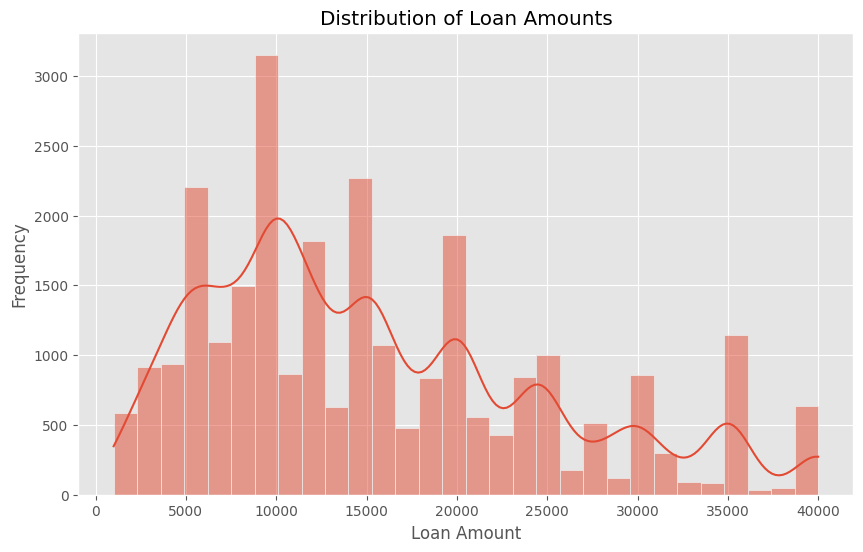

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(fintech_df['Loan Amount'], bins=30, kde=True)
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

This shows that the 'Loan amount' has a right-skewed distribution.

## Question 2: What is the correlation between the columns in the dataset?

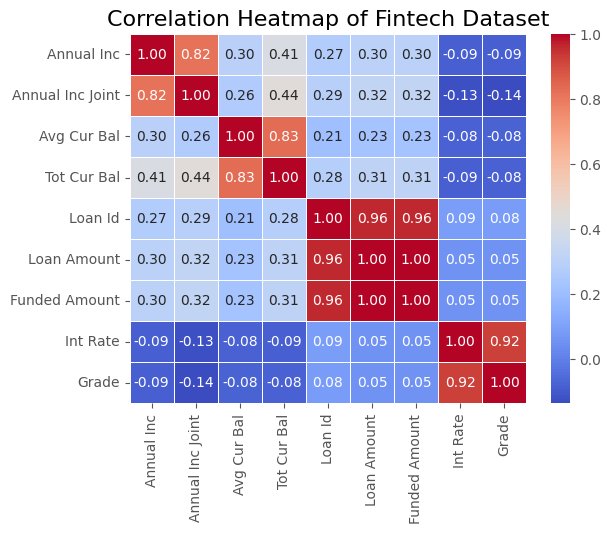

In [32]:
correlation_matrix = fintech_df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Fintech Dataset', fontsize=16)
plt.show()

This shows that 'Loan Amount' and 'Funded Amount' have a strong positive correlation.
This raises another question, are these columns duplicated?

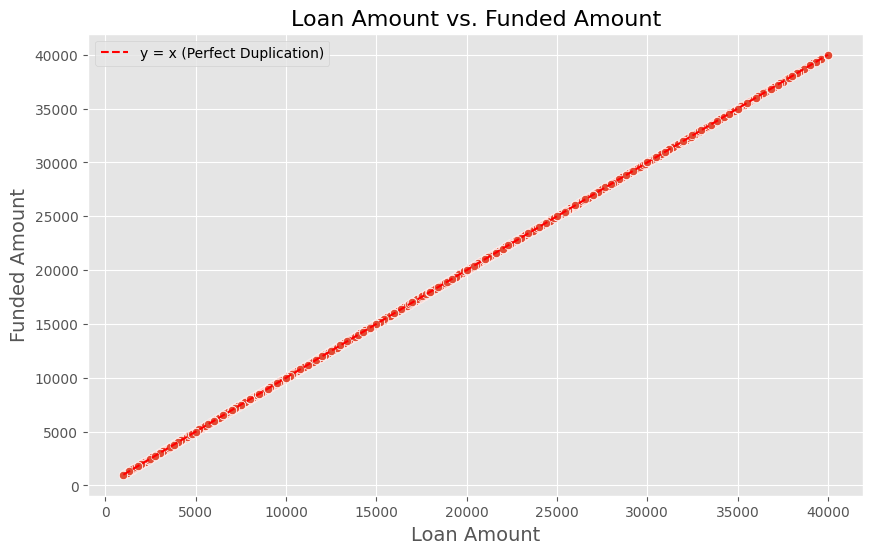

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Loan Amount', y='Funded Amount', data=fintech_df)
plt.plot([fintech_df['Loan Amount'].min(), fintech_df['Loan Amount'].max()],
         [fintech_df['Loan Amount'].min(), fintech_df['Loan Amount'].max()], 
         color='red', linestyle='--', label='y = x (Perfect Duplication)')
plt.title('Loan Amount vs. Funded Amount', fontsize=16)
plt.xlabel('Loan Amount', fontsize=14)
plt.ylabel('Funded Amount', fontsize=14)
plt.legend()
plt.show()

We can see that this is a perfect straight line, so we can say that the columns `Loan Amount` and `Funded Amount` are duplicated.
We can do one more check to confirm that:

In [34]:
len(fintech_df[fintech_df['Loan Amount'] != fintech_df['Funded Amount']])

0

## Question 3: What are the most common Loan purposes?

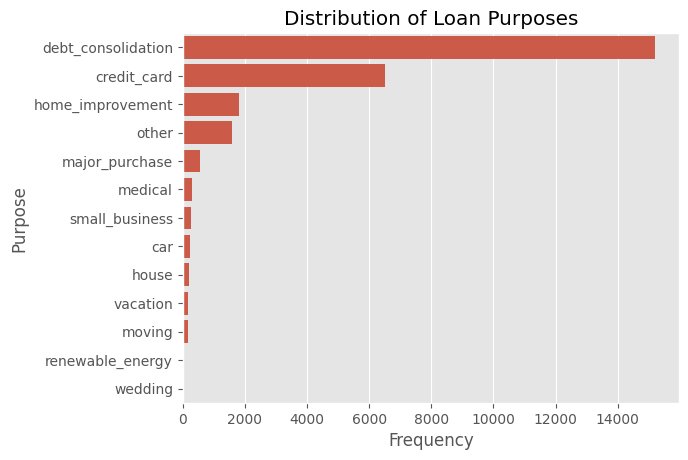

In [35]:
sns.countplot(y='Purpose', data=fintech_df, order=fintech_df['Purpose'].value_counts().index)
plt.title('Distribution of Loan Purposes')
plt.xlabel('Frequency')
plt.ylabel('Purpose')
plt.show()

We can see that most of the loans are made for `debt_consolidation` and `credit_card` and the rest of the purposes have a small number of occurences.

## Question 4: What is the distribution of employment lengths among borrowers?

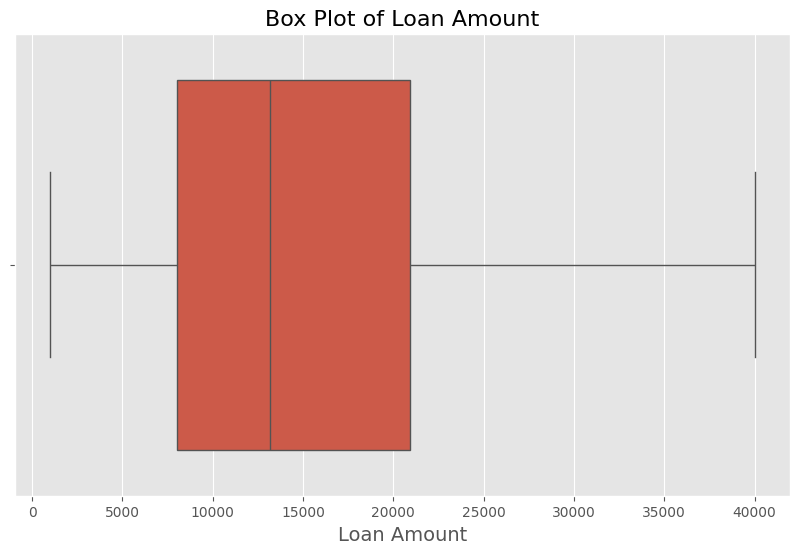

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Loan Amount', data=fintech_df)
plt.title('Box Plot of Loan Amount', fontsize=16)
plt.xlabel('Loan Amount', fontsize=14)
plt.show()

This shows the central tendency of the loan amount and also shows that there are no outliers in this field.

## Question 5: How does the loan status relate to the length of employment (Emp Length)?

C:\Users\omar1\AppData\Local\Temp\ipykernel_3128\2559103521.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Home Ownership', y='Annual Inc', data=avg_income_by_home_ownership, palette='viridis')


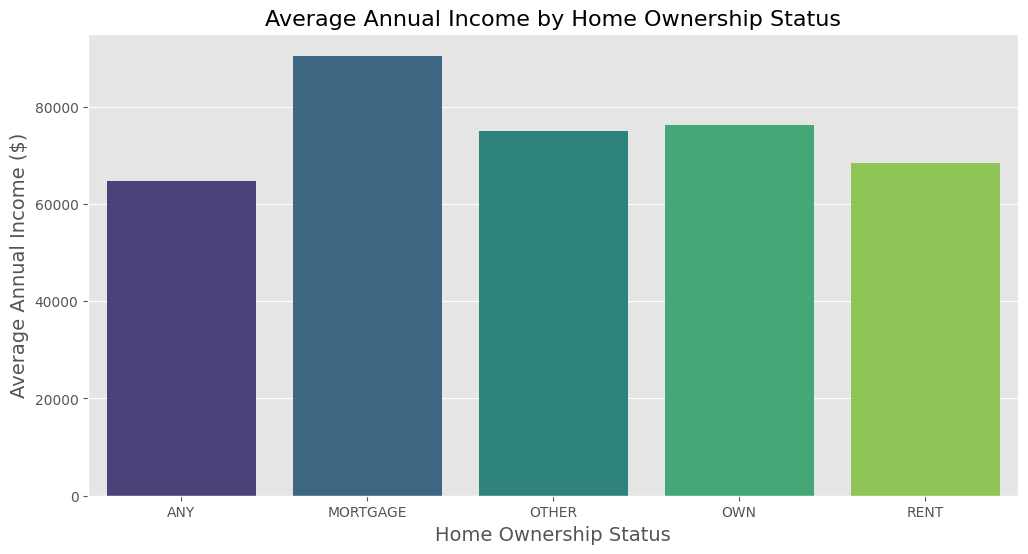

In [37]:
avg_income_by_home_ownership = fintech_df.groupby('Home Ownership')['Annual Inc'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Home Ownership', y='Annual Inc', data=avg_income_by_home_ownership, palette='viridis')
plt.title('Average Annual Income by Home Ownership Status', fontsize=16)
plt.xlabel('Home Ownership Status', fontsize=14)
plt.ylabel('Average Annual Income ($)', fontsize=14)
plt.show()

# 3 - Cleaning Data

## Tidying up column names

In [38]:
def rename_columns(df):
    df.columns = df.columns.str.lower()
    df.columns = [col.replace(' ', '_') for col in df.columns]

In [39]:
rename_columns(fintech_df)
fintech_df.columns

Index(['emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'annual_inc_joint', 'verification_status', 'zip_code', 'addr_state',
       'avg_cur_bal', 'tot_cur_bal', 'loan_id', 'loan_status', 'loan_amount',
       'state', 'funded_amount', 'term', 'int_rate', 'grade', 'issue_date',
       'pymnt_plan', 'type', 'purpose', 'description'],
      dtype='object')

## Observe inconsistent data

In [40]:
consistent_df = fintech_df.copy()

In [41]:
def replace_value(df, column_name, old_value, new_value):
    df[column_name] = df[column_name].replace({old_value:new_value})

Fixing inconsistent data in `type` column

In [42]:
replace_value(consistent_df, 'type', 'Individual', 'INDIVIDUAL')
replace_value(consistent_df, 'type', 'Joint App', 'JOINT')

consistent_df['type'].unique()

array(['INDIVIDUAL', 'JOINT', 'DIRECT_PAY'], dtype=object)

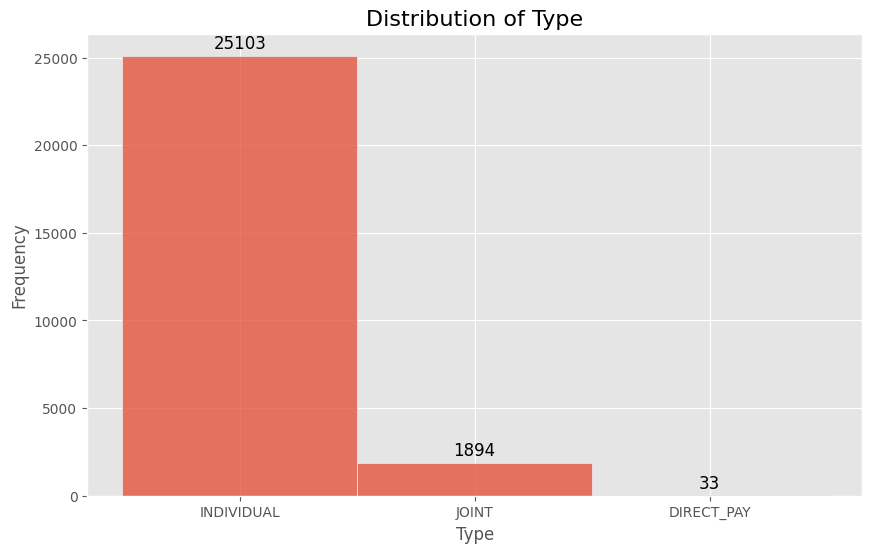

In [43]:
plt.figure(figsize=(10,6))
ax = sns.histplot(consistent_df['type'])
plt.title('Distribution of Type', fontsize=16)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'baseline', 
                fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.show()

Removing `ANY` and `OTHER` from `home_ownership` column as they are not expected

In [44]:
replace_value(consistent_df, 'home_ownership', 'OTHER', 'ANY')

consistent_df['home_ownership'].unique()

array(['MORTGAGE', 'RENT', 'OWN', 'ANY'], dtype=object)

Fixing inconsistent data in `emp_title` column

There are many entries that have different capitalization and trailing spaces so we can start with that.

In [45]:
consistent_df['emp_title'] = consistent_df['emp_title'].str.lower().str.strip()

In [46]:
# consistent_df[consistent_df['emp_title'].str.lower().str.startswith('maintena')]['emp_title'].unique()

Changing some entries in `emp_title` that have the same value but are written in different ways.

In [47]:
replace_value(consistent_df, 'emp_title', 'maintenace', 'maintenance')
replace_value(consistent_df, 'emp_title' ,'sales and man', 'sales and management')

len(consistent_df['emp_title'].unique())

10996

Dropping `Description` since it has inconsistent data and is duplicated from `Purpose`

In [48]:
consistent_df = consistent_df.drop('description', axis=1)
consistent_df.shape,consistent_df.columns

((27030, 22),
 Index(['emp_title', 'emp_length', 'home_ownership', 'annual_inc',
        'annual_inc_joint', 'verification_status', 'zip_code', 'addr_state',
        'avg_cur_bal', 'tot_cur_bal', 'loan_id', 'loan_status', 'loan_amount',
        'state', 'funded_amount', 'term', 'int_rate', 'grade', 'issue_date',
        'pymnt_plan', 'type', 'purpose'],
       dtype='object'))

### Checking if `state` and `addr_state` are duplicated

In [49]:
len(consistent_df[consistent_df['state'] == consistent_df['addr_state']])

27030

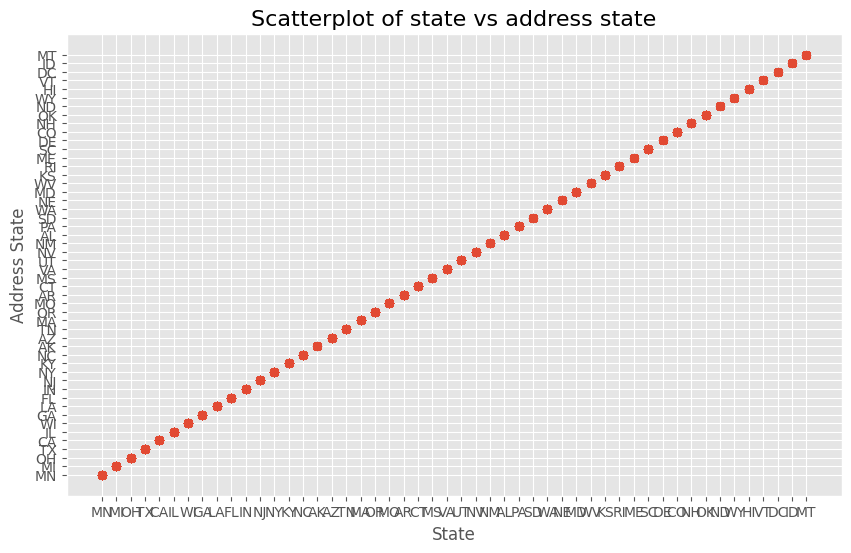

In [50]:
plt.figure(figsize=(10,6))
plt.scatter(consistent_df['state'], consistent_df['addr_state'], alpha=1)
plt.title('Scatterplot of state vs address state', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Address State', fontsize=12)
plt.show()

We can see that the values in `state` and `addr_state` in all entries are the same. Therefore we can disregard one of them.

In [51]:
# consistent_df = consistent_df.drop('addr_state', axis=1)
# consistent_df.shape,consistent_df.columns

After considering this once again, I decided to not drop the `addr_state` column as it does not represent the same concept of `state` even though all their values are equal.

The last 2 operations decreased the number of columns we have in the dataset from 23 down to 22.

### Checking for inconsistency in `home_ownership`

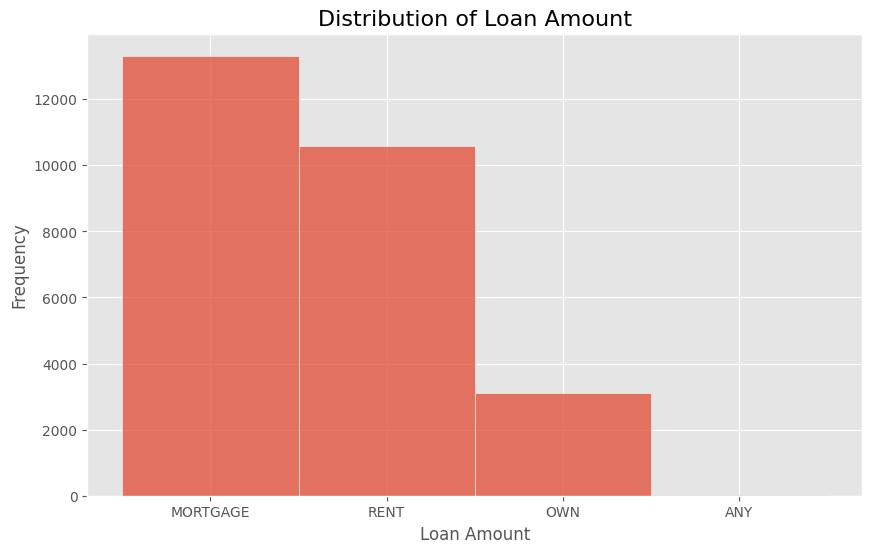

In [52]:
plt.figure(figsize=(10,6))
sns.histplot(consistent_df['home_ownership'])
plt.title('Distribution of Loan Amount', fontsize=16)
plt.xlabel('Loan Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Are `ANY` or `OTHER` considered missing values?

### Changing data type of `issue_date` from object to datetime

In [53]:
consistent_df['issue_date'] = pd.to_datetime(consistent_df['issue_date'])
consistent_df['issue_date'].unique()

<DatetimeArray>
['2018-10-18 00:00:00', '2016-02-16 00:00:00', '2015-07-15 00:00:00',
 '2016-12-16 00:00:00', '2019-01-19 00:00:00', '2017-09-17 00:00:00',
 '2015-04-15 00:00:00', '2018-12-18 00:00:00', '2019-10-19 00:00:00',
 '2018-07-18 00:00:00', '2018-03-18 00:00:00', '2018-08-18 00:00:00',
 '2016-05-16 00:00:00', '2015-05-15 00:00:00', '2016-07-16 00:00:00',
 '2013-08-13 00:00:00', '2015-11-15 00:00:00', '2015-09-15 00:00:00',
 '2014-09-14 00:00:00', '2017-04-17 00:00:00', '2014-11-14 00:00:00',
 '2018-09-18 00:00:00', '2017-11-17 00:00:00', '2013-04-13 00:00:00',
 '2019-05-19 00:00:00', '2014-04-14 00:00:00', '2017-10-17 00:00:00',
 '2016-03-16 00:00:00', '2014-06-14 00:00:00', '2015-01-15 00:00:00',
 '2019-04-19 00:00:00', '2015-06-15 00:00:00', '2019-02-19 00:00:00',
 '2018-04-18 00:00:00', '2014-07-14 00:00:00', '2019-09-19 00:00:00',
 '2012-12-12 00:00:00', '2019-03-19 00:00:00', '2017-01-17 00:00:00',
 '2013-02-13 00:00:00', '2015-10-15 00:00:00', '2014-05-14 00:00:00',
 '20

## Observing Missing Data

Taking a look at how much of the data is missing once again

In [54]:
missing_values = consistent_df.isnull().sum()
missing_columns = missing_values[missing_values > 0]
missing_info_df = pd.DataFrame({
    'Column': missing_columns.index,
    'Missing Values': missing_columns.values,
    'Data Type': [consistent_df[col].dtype for col in missing_columns.index]
})
missing_info_df.sort_values(by='Missing Values')

,Column,Missing Values,Data Type
3,int_rate,1193,float64
1,emp_length,1809,object
0,emp_title,2320,object
2,annual_inc_joint,25136,float64


### First lets check `annual_inc_joint` because it might be MNAR.

In [55]:
consistent_df[consistent_df['annual_inc_joint'].isnull()].groupby('type').size()

type
DIRECT_PAY       33
INDIVIDUAL    25103
dtype: int64

Missing values for joint income are because not all loans are joint applications and therefore are MNAR. As shown, the missing values only occur for `INDIVIDUAL` or `DIRECT_PAY` types.

In order to solve the missing values in `annual_inc_joint` I will fill null values with 0 since the missing values indicate that it does not exist.

In [56]:
consistent_df['annual_inc_joint_original'] = consistent_df['annual_inc_joint'].copy()
consistent_df['annual_inc_joint'] = consistent_df['annual_inc_joint'].fillna(value=0)

### Checking the missing values of `int_rate`

In [57]:
consistent_df[consistent_df['int_rate'].isnull()].sample(10)

,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_status,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original
Customer Id,,,,,,,,,,,,,,,,,,,,,,,
Yid0blx4ODReXHhmMVx4ZDRceGI3XHhmNiooXHgwNVx4YjFceGMwIlx4ZDd6PVx4ZGYyXHg4Ylx4MDRceGQ1Olx4ODFcdFx4ODEzXHhkMVwnXHhhYSRceGQxJw==,busser,9 years,MORTGAGE,28000.0,0.0,Not Verified,751xx,TX,1790.0,14319.0,99220,Current,10000.0,TX,10000.0,36 months,NaN,17,2019-04-19,False,INDIVIDUAL,credit_card,NaN
YicoXHhhMVx4ODhceGU2XHhlM1x4OTJceGU3XHhhOXNceDEwXHhhZDVceGRhXHg5ZVxuXHgwZnRuXHhjN1x4ZTMwXHhhZlx4YjF8XHhiZlRceDA1XHhiNDFceGIybjQn,cardiovascular perfusionist,< 1 year,OWN,105000.0,0.0,Verified,117xx,NY,8844.0,114969.0,233469,Current,27000.0,NY,27000.0,60 months,NaN,12,2014-02-14,False,INDIVIDUAL,credit_card,NaN
YidceGI3blx4OWN1Q1x4YTZceGYyXHgxYVx4MWRceGU2XHg4MVx4ZTJTXHhmN1x4MWRgIlx4ZGRceDAzXHgwZjJceGVjXHhkYVpceGZiXHg5YVx4YTFceGYzXHhmODBceDg1KSc=,registered nurse,10+ years,MORTGAGE,130000.0,0.0,Not Verified,910xx,CA,49585.0,297508.0,114694,Current,11825.0,CA,11825.0,36 months,NaN,15,2019-11-19,False,INDIVIDUAL,debt_consolidation,NaN
Yid9XHhiN1x4ZDJceGY1XHhkMVx4OGMuXHhhOFx4ZWVRXHgwNE5ceDAwXHhmYlx4YzZceGNiaVx4ZDl2XHhkMFx4YmFceDk4XlQgTVx4YzhceGI2XHgxYlhceGE2ICc=,staff accountant,4 years,MORTGAGE,72252.0,0.0,Verified,926xx,CA,10778.0,75445.0,244188,Fully Paid,30000.0,CA,30000.0,60 months,NaN,7,2015-10-15,False,INDIVIDUAL,credit_card,NaN
YidceDliZ1x4YTFZZVx4ZjA8XHhkN1x4ODlWYVx4ODlceGVmXHgxOVx4YmY1XHhjNVx0KGZceGIyWFx4YWJceGIyXHhmNytceDE2XHhhMiVceGRlP0cn,consultant,1 year,MORTGAGE,75000.0,0.0,Not Verified,775xx,TX,17352.0,190873.0,10657,Current,3000.0,TX,3000.0,36 months,NaN,7,2014-08-14,False,INDIVIDUAL,debt_consolidation,NaN
YiIsJ1x4ZGJceGZkXHhlY1tceGNjXHgxYVx4OWNWXHhkMSBceDgxXHhhY1x4YzhceGQ4XHhmMWZbXHhkZVRceGVid0dceGRjXHhmNlx4ZDlGUlx4Y2ZFTyI=,enginner,10+ years,MORTGAGE,80000.0,0.0,Verified,950xx,CA,121839.0,609197.0,137402,Fully Paid,14000.0,CA,14000.0,36 months,NaN,2,2013-12-13,False,INDIVIDUAL,credit_card,NaN
Yic0XHhjZFx4YjFceGY2P1x4OWJOXHhlM1x4YjhceGZkXHg3Zlx4MDVceDEyXHhmMlx4OWEpbjpceGU4XHhjMlx4MTNceDBlXHhkNjhceDFjXHhiOENceGI3XHg4Mlx4MDNceGNiXHgwYyc=,payroll coordinator,2 years,RENT,50000.0,0.0,Not Verified,903xx,CA,21054.0,84217.0,136166,Current,13500.0,CA,13500.0,36 months,NaN,10,2018-12-18,False,INDIVIDUAL,debt_consolidation,NaN
Yic+PTJceGE2XG5ceDgyXVJceGE1fVx4ZGVceDliXHhiNVx4MWIzaitceGJjXHgwZlx4YjBYXHhlOVx4MGZceGVlXHhhNTMtZlx4ZWVceGMyUFx4ZDAn,window installation,5 years,MORTGAGE,88000.0,0.0,Source Verified,956xx,CA,74541.0,372704.0,156951,Current,15000.0,CA,15000.0,60 months,NaN,14,2019-04-19,False,INDIVIDUAL,debt_consolidation,NaN
YidXMFx4ZjNTW1x4MTVceDBmXHg4NFx4YmJceGE1XHhiNFx4MTdPXHg5MHRceGI5IypceGU3Klx4MWZceGZmRFx4YjhSXHgwNFx4MTZceDE4XHhlYS9ceGJlSic=,outside sales,10+ years,MORTGAGE,98000.0,0.0,Not Verified,917xx,CA,52963.0,423704.0,18694,Current,4000.0,CA,4000.0,36 months,NaN,15,2017-06-17,False,INDIVIDUAL,debt_consolidation,NaN


from looking at multiple samples, we can say that there might be a correlation between `int_rate`'s missing values and not having a `pymnt_plan`

Let's check if that is the case

In [58]:
consistent_df[consistent_df['int_rate'].isnull()].groupby('pymnt_plan').size()

pymnt_plan
False    1193
dtype: int64

This shows that all the records with missing values in `int_rate` have `False` in `pymnt_plan`.

However, this is not a good correlation since this is not the case for all `False` entries in `pymnt_plan`.

In [59]:
consistent_df[~consistent_df['int_rate'].isnull()].groupby('pymnt_plan').size()

pymnt_plan
False    25834
True         3
dtype: int64

Earlier we found that there is a correlation between `int_rate` and `grade` of 0.92. So we can use the grade to impute the missing values in `int_rate`. Therefore, the missing values in `int_rate` are MAR.

In [60]:
consistent_df['int_rate'] = consistent_df.groupby('grade')['int_rate'].transform(lambda x: x.fillna(x.median()))
consistent_df['int_rate'].isnull().sum()

0

In [61]:
# mode = consistent_df['int_rate'].mode()
# consistent_df['int_rate'] = consistent_df.groupby('grade')['int_rate'].transform(lambda x: x.fillna(x.mode() if not x.mode().empty else mode))
# consistent_df['int_rate'].isnull().sum()

In [62]:
consistent_df[consistent_df['int_rate'].isnull()]

,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_status,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original
Customer Id,,,,,,,,,,,,,,,,,,,,,,,


In [63]:
len(consistent_df.groupby('grade')['int_rate'].mean()),consistent_df.groupby('grade')['int_rate'].mean()

(35,
 grade
 1     0.072187
 2     0.072710
 3     0.072383
 4     0.072533
 5     0.072215
 6     0.108864
 7     0.108813
 8     0.108632
 9     0.108526
 10    0.108268
 11    0.144266
 12    0.143826
 13    0.144583
 14    0.144176
 15    0.144295
 16    0.187683
 17    0.187391
 18    0.188097
 19    0.187468
 20    0.188695
 21    0.219909
 22    0.221359
 23    0.218947
 24    0.220234
 25    0.221812
 26    0.256864
 27    0.261073
 28    0.255160
 29    0.252161
 30    0.260352
 31    0.277696
 32    0.283410
 33    0.287904
 34    0.286670
 35    0.283563
 Name: int_rate, dtype: float64)

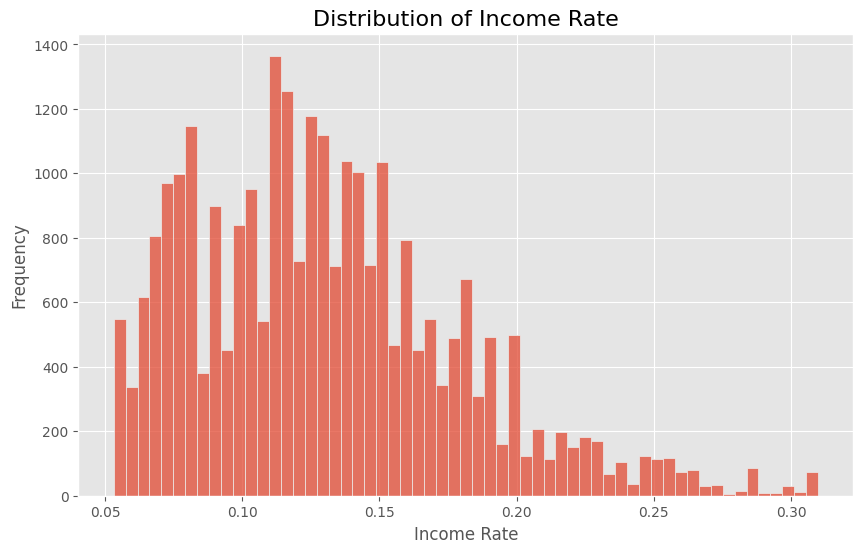

In [64]:
plt.figure(figsize=(10,6))
sns.histplot(consistent_df['int_rate'])
plt.title('Distribution of Income Rate', fontsize=16)
plt.xlabel('Income Rate', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Checking the missing values of `emp_length`

In [65]:
consistent_df[consistent_df['emp_length'].isnull()].sample(10)

,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_status,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original
Customer Id,,,,,,,,,,,,,,,,,,,,,,,
YidceDBjXHgxZFx4ODFceGU4XHgxMUFceGQ0KnIwXHhmMFx4MWUiXHhmMipceGI3XHhjYlx4OTg2XHgwNlx4YmJceDhkSVx4MGJsXHgxMlx4ZjhceDhlXHhiN1x4ZmVceGY1XHgxMyc=,NaN,NaN,MORTGAGE,115000.0,0.0,Source Verified,281xx,NC,2855.0,71363.0,95412,Current,10000.0,NC,10000.0,36 months,0.1407,15,2018-03-18,False,INDIVIDUAL,home_improvement,NaN
YiJLXlx4YWJ1XG5ceDA1NVx4MTlceGNjXHhjNFx4ZDNceDA3am9ceGE2XHg5YydceGMxYjBceDk2XHgwMVx4OTVmYVx4OTcuXHg5YVx4YzQ5LVx4Y2Ii,NaN,NaN,RENT,58000.0,0.0,Verified,490xx,MI,2578.0,20620.0,209718,Charged Off,22000.0,MI,22000.0,36 months,0.1875,18,2013-05-13,False,INDIVIDUAL,debt_consolidation,NaN
YidceGIwXVx4ZjFceGQzXHhjNVx4ODB9LVx4MDNceDk1XHhkMlx4ZTBhXHg5NFx4MDNEXHgwM1x4MTdcXFx4YTJceDAwXHhlNFx4YWJQXHg4Zlx4ZTJceDFkSi5WYX0n,NaN,NaN,OWN,96000.0,0.0,Verified,680xx,NE,14006.0,308132.0,205718,Charged Off,21000.0,NE,21000.0,60 months,0.1099,7,2015-10-15,False,INDIVIDUAL,home_improvement,NaN
YidceDE2c1x4YjkoXHhmNFx4YzNceGU5XHhkYWpceDEwXHhjNFx4MWRceDk5eFx4MTBceDA4XHhlND9ceDlhXHgxZD5CXHgxN1x4ZDBcXE5YNFx4Y2JceGNlXHhkOWcn,NaN,NaN,RENT,8796.0,0.0,Verified,304xx,GA,1128.0,4511.0,12623,Fully Paid,3125.0,GA,3125.0,36 months,0.1854,24,2015-01-15,False,INDIVIDUAL,debt_consolidation,NaN
YidceDkyXHhjMlx4MWFceGY3Ll9ceDE4XHhhMFx4ZjFFYVtAXHgxYVx4MWFceGI5XHhiNmBceDk1XHhjZFx4YWFceGFlXHhiNFx4ZWVgXHhmOFFJXHg5Ylx4YmJceDljXHhjNSc=,NaN,NaN,RENT,30000.0,0.0,Verified,982xx,WA,2163.0,21632.0,77014,Charged Off,9000.0,WA,9000.0,36 months,0.1899,22,2015-11-15,False,INDIVIDUAL,debt_consolidation,NaN
YidceDExXHgwMFx4ZWJuPlx4YTUkJFx4MDRgXHgwN05IXHgxMlx4YzlceGYwXHgwY1x4OTdceGVhXHgxYlx4Y2NkXHhmMVx4ZDh2XHhkNm5ceGIzXHhjMlx4ZDBceGM0XHhhNSc=,NaN,NaN,MORTGAGE,62000.0,0.0,Verified,986xx,WA,22612.0,271347.0,224676,Fully Paid,25000.0,WA,25000.0,36 months,0.1269,15,2015-03-15,False,INDIVIDUAL,debt_consolidation,NaN
YiJceDliXHhlMlx4MTJceGI0YFx4MDhAOydceDllXHhmMThceDk2XHg4ZFx4OTlceGY1XHgwYn5ceGQ4I1x4ZTg+UEhceGExXHhiY0V3XHhiM1x4YTFceDkyXHg5ZiI=,NaN,NaN,MORTGAGE,20000.0,0.0,Verified,386xx,MS,11888.0,71325.0,9109,Current,3000.0,MS,3000.0,36 months,0.0672,2,2017-12-17,False,INDIVIDUAL,debt_consolidation,NaN
YidceGEwXHhkYlx4YWVceDA1XHhhZVx4YjJceGZjMjJceGIzXHhkYjBceGQyXHhjY1x4MTJceGM4XHhhMChceGNmXHhhOVx4Y2JceDk4XHhhZlx4Yzlcclx4MDVceGI4XHg5ZHdceGI2XHhkNFx4Y2Yn,NaN,NaN,ANY,48000.0,0.0,Not Verified,346xx,FL,9620.0,96202.0,74838,Current,9000.0,FL,9000.0,36 months,0.0756,1,2019-09-19,False,INDIVIDUAL,credit_card,NaN
YidceDEwVE5ceGI1XHhjYitceDE0XHhjZCFceGM0XHhiOVx4ZmVceDg0XHgwMkoyXHhhY1x4ZWRceDE3SFx4OWRiOVtEWVx4ZTlceGUzUlx4ODhLPyc=,NaN,NaN,MORTGAGE,80000.0,0.0,Not Verified,469xx,IN,2258.0,15804.0,218628,Current,24000.0,IN,24000.0,60 months,0.1349,12,2016-10-16,False,INDIVIDUAL,debt_consolidation,NaN


This hints that there might be a correlation between `emp_title` and `emp_length` missing values.
Let's check it out.

In [66]:
empty_length = consistent_df['emp_length'].isnull()
empty_title = consistent_df['emp_title'].isnull()
len(consistent_df[empty_length & empty_title])

1802

We can see that all but 7 entries that have a null in `emp_length` have a null in 'emp_title` as well. Let's look at the remaining 7 entries.

In [67]:
consistent_df[empty_length & ~empty_title]

,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_status,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original
Customer Id,,,,,,,,,,,,,,,,,,,,,,,
YidceGZiIDwibFx4ZmJwXHhkZVx4ODFceGM5QUdceGJlXHgwZVx4OTZEc1x4ZWZfe1x4ZTErXHgwMEY5XHhmOFx4ZDQ3XHhmNlx4ZTNceGRkXHhjMSc=,emt,NaN,MORTGAGE,130000.0,0.0,Source Verified,109xx,NY,22104.0,331558.0,261407,Current,35000.0,NY,35000.0,60 months,0.2075,22,2016-05-16,False,INDIVIDUAL,debt_consolidation,NaN
YidceGMyXHhhOStceGZmXHhmOGlceDE5LVx4Y2ZceGJlXHhkM29hRXdlRFx4MDdceDg4XHhjOFx4ZTVceDExO1x4YjY/b1xcYjM1UFx4ZmUn,psychologist,NaN,MORTGAGE,55200.0,0.0,Not Verified,857xx,AZ,39021.0,195107.0,22167,Current,4500.0,AZ,4500.0,36 months,0.1102,10,2019-05-19,False,INDIVIDUAL,credit_card,NaN
YicrXHg5YnRceDgxLFx4ZWNceDgzVExceDE3Ilx4MWJceGY5XHhhYVx4MTNcdGlceGFjXHhhM1x4OWVvNlx4YWVceGVhXHhlM0ZceGFkXHhjM1x4OWJceGQzPlx4ODEn,corrections officer,NaN,RENT,65000.0,0.0,Source Verified,166xx,PA,7495.0,29981.0,119052,Current,12000.0,PA,12000.0,36 months,0.0949,8,2014-11-14,False,INDIVIDUAL,credit_card,NaN
YidceGRhXHhmN1x4YjhceDFjZkJceGMzQ1x4ZWRceGQ2fFx4ZjNrXHhhN1x4MDRceGY0N1hFXHhhNnNceGFjYVx4OWNceDE1S1x4ZTJceGRkeVx4ZTFceDljXHhjZic=,owner,NaN,OWN,70000.0,0.0,Source Verified,496xx,MI,5860.0,23443.0,225280,Late (31-120 days),25000.0,MI,25000.0,36 months,0.1557,15,2019-06-19,False,INDIVIDUAL,debt_consolidation,NaN
YidceGNlXHgwMFNceGM3bVx4YmN3XHhjZVx4ZjVAI1x4YzJceGZmXHhiYlx4OTVceDBjXHhlNVx4ZTZceGE0XHhhN1x4YmZTXHhiZlx4MDVceDFjXHhjOFx4MTduKlx4ZTg5XHhhZic=,sales and management,NaN,RENT,109375.0,0.0,Verified,301xx,GA,9827.0,78616.0,133231,Charged Off,13000.0,GA,13000.0,36 months,0.1049,10,2016-09-16,False,INDIVIDUAL,debt_consolidation,NaN
YidceGE0XHg4MFx4OWVceGVkOlx4MWRceGJhXHhhYlBceDE5dVFceDliXHgwYlx4Y2NceGUxXHhjMVx4OGJhQi1ceDE4Z1x4ZDNceGMyXHgwNVx4YTNceGI5XHhhY1x4MDZceGI0JCc=,maintenance,NaN,RENT,32000.0,0.0,Verified,456xx,OH,3088.0,24709.0,63759,Current,8000.0,OH,8000.0,36 months,0.0839,9,2016-03-16,False,INDIVIDUAL,credit_card,NaN
YidceDBmTVxcXHhjYlQ8XHhmNElzc1x4MTVqXHhkZlx4YTlceGNjXHhjMVx4MTZGXHgxMGkoXHg5ZFx4YzlxXHgxOVx4ZDVceGFkXHhjNVx4YzhceDAwXHhlMlx4ZTMn,driver,NaN,RENT,64500.0,0.0,Source Verified,923xx,CA,4270.0,25619.0,123707,Charged Off,12000.0,CA,12000.0,36 months,0.1786,19,2015-04-15,False,INDIVIDUAL,debt_consolidation,NaN


We can conclude that `emp_length` and `emp_title` are MCAR because there are no relation between the missing values and any other available attribute in the dataset.

### Checking the missing values in `emp_title`

In [68]:
consistent_df[consistent_df['emp_title'].isnull()]

,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_status,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original
Customer Id,,,,,,,,,,,,,,,,,,,,,,,
YidwXHg5MXFceDEzXHJceGYxXHg4OVx4ZjVceGJkXHgxZVx4MTZceGUwXHhmOVx4ZTlceDgwOlx4YzhceGFkXHhkOFx4ZTRceGVkXHhlYlx4YmNceGI0Jlx4YTVceGE3XHhlN1x4YzZccmxceGEwJw==,NaN,2 years,MORTGAGE,80000.0,0.0,Not Verified,752xx,TX,8321.0,124817.0,67995,Current,8000.0,TX,8000.0,36 months,0.1447,15,2018-08-18,False,INDIVIDUAL,credit_card,NaN
YiJ5XHhkNVx4OWJcdCo0XHgwZVx4YWFCLFx4OTB5XHgxYilceDk4S1FceGMwXHhmMFx4YTVceGVhXHg5MnlFQVx4MTJceDA0RVx4YWZceDhmXHhjMSci,NaN,NaN,MORTGAGE,73000.0,0.0,Verified,960xx,CA,51881.0,466933.0,111984,Current,11200.0,CA,11200.0,36 months,0.0819,5,2014-11-14,False,INDIVIDUAL,debt_consolidation,NaN
YidceGFlXHg5ZFx4MDg0XHg4ZVx4YTQsXHhhYzhZXHgxZXtceGM2XHhiNlx4ZDBceGMwXHgwMFx4YzBceDAzQSRceGZlXHhjZlx4MTNceGJhXHhkYVlCXHgxZFx4YTVcdFx4ODYn,NaN,NaN,OWN,31000.0,0.0,Verified,641xx,MO,3795.0,18975.0,74058,Fully Paid,8925.0,MO,8925.0,36 months,0.1433,14,2015-11-15,False,INDIVIDUAL,debt_consolidation,NaN
YidceDhjaVx4ZDI/KFx4MWJceDFmSVx4OTVEXHg5OFx4OWJceGEyXHhmYyI3Q1x4MGVceGViXHg5Ylx4OThceGUxXHg5NFx4ZWF1XHg5MDViXyJ2XHg4NCc=,NaN,NaN,MORTGAGE,60000.0,120000.0,Source Verified,443xx,OH,1912.0,15298.0,111534,Current,11050.0,OH,11050.0,36 months,0.2565,17,2019-10-19,False,JOINT,debt_consolidation,120000.0
YidVcCJceGRiXHhkMTtceGU3XHg5MVx4OWNceGM0XHgxZlx4ZWJceGRjXHhjMExceDE4QFx4ODQpXHhhYz1ceGU5JVx4YjFTXHhlMFx4N2ZceGM0XHhmM1x4OGF4XHg4MCc=,NaN,NaN,OWN,35000.0,0.0,Not Verified,337xx,FL,6609.0,59483.0,63878,Current,8000.0,FL,8000.0,36 months,0.0881,5,2019-10-19,False,INDIVIDUAL,debt_consolidation,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YidceDEwXHhmNmVceGViRTIiMVx4N2Y7XHhkNzVcbndceDg0XHhlMGVLXHhhMi9ceGNhXHgwOFx4ODFceGRkXHg5MjRceDA1SUFceGFiZ3En,NaN,NaN,OWN,39000.0,0.0,Not Verified,611xx,IL,771.0,10018.0,97274,Current,10000.0,IL,10000.0,36 months,0.1614,12,2018-11-18,False,INDIVIDUAL,debt_consolidation,NaN
YiJUfmJceGIwLD1ceGQ3OFdceGQyW1xcXHhjMlx4ZWNPQFx4YmJceGUyXHhmMlx4YTE/XHhkMVx4ZjFceGFlXHhmMVx4YmFceDFhXHhlYjgnXHhmM2si,NaN,< 1 year,MORTGAGE,50000.0,0.0,Not Verified,941xx,CA,6782.0,47471.0,211825,Current,22800.0,CA,22800.0,36 months,0.1180,10,2019-01-19,False,INDIVIDUAL,credit_card,NaN
YidceGQ4XHg4ZVx4YTBceGY3ZDh5XHhkMVx4YWJceGM5JFx4ZjJceGNjXHg4NXVaXHhjMFx4ZmRceDAzXHgxOFx4OTc+XHgxYlx4YWVJXHhiMyJceGRhXHhkZFlceGFkSyc=,NaN,10+ years,MORTGAGE,75492.0,0.0,Verified,070xx,NJ,15506.0,279104.0,97941,Charged Off,10000.0,NJ,10000.0,36 months,0.1756,16,2013-07-13,False,INDIVIDUAL,credit_card,NaN


In [69]:
consistent_df['annual_inc'].min(), consistent_df['annual_inc'].max()

(300.0, 5541120.0)

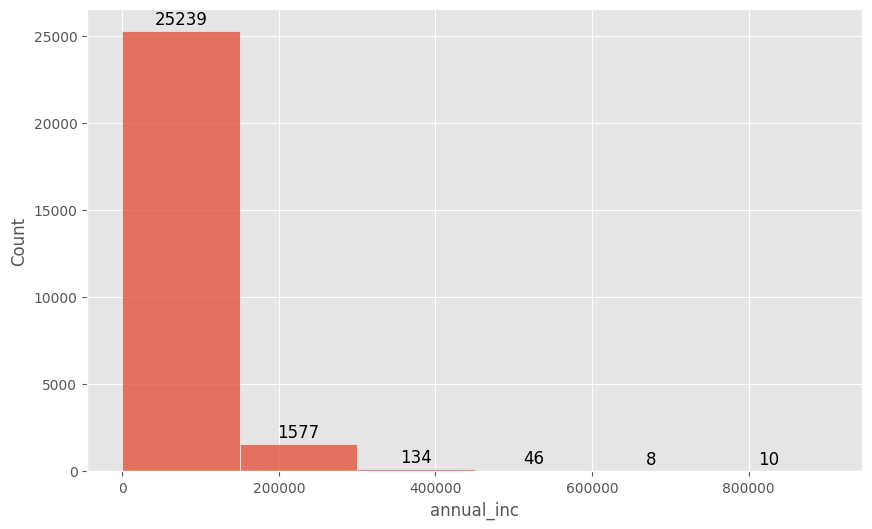

In [70]:
annual_inc_col = consistent_df[consistent_df['annual_inc'] < 1e6]['annual_inc']
plt.figure(figsize=(10,6))
ax = sns.histplot(annual_inc_col, bins=6)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'baseline', 
                fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.show()


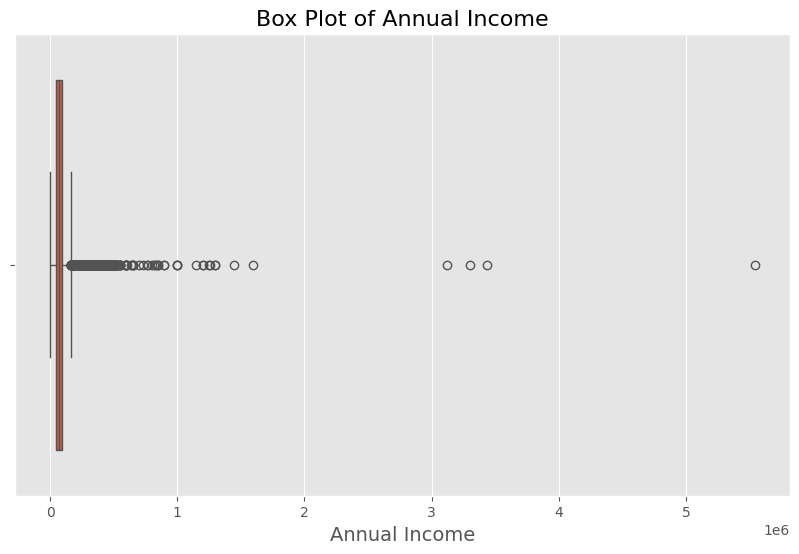

In [71]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='annual_inc', data=fintech_df)
plt.title('Box Plot of Annual Income', fontsize=16)
plt.xlabel('Annual Income', fontsize=14)
plt.show()

In [72]:
consistent_df[consistent_df['annual_inc'] > 1e6]

,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_status,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original
Customer Id,,,,,,,,,,,,,,,,,,,,,,,
YidceDA1YiUoRlx4MDJceGMyXHhkN1x4ZjVceGZmXHhiZFx4ZjNceGY5XHg4MzI+XHhjN1x4MDZceGM0XHgxNVx4ZTJceGQ3XHgwN1x4MGNceGY1dk1ceGY4XHhhZFx0XHhiZlx4Zjgn,vice president,10+ years,MORTGAGE,1450000.0,1465000.0,Verified,926xx,CA,24819.0,372289.0,265013,Current,40000.0,CA,40000.0,36 months,0.0735,2,2019-10-19,False,JOINT,debt_consolidation,1465000.0
YiJceDg5Mlx4ZTRceDg4eFx4YzgnXHhkMFx4OGRHeVx4ZjEyXHhmYkxIXHhlNlx4MThceDE0TF9OUVx4ZTVceGJkXHhkNlx4ZTBceGJjXHgxZFpceGMwWSI=,partner,4 years,OWN,1300000.0,0.0,Verified,601xx,IL,121273.0,2061648.0,260358,Current,35000.0,IL,35000.0,60 months,0.1709,20,2017-10-17,False,INDIVIDUAL,debt_consolidation,NaN
YidceGIySVx4YjVceGFicDtceDk2JVx4MGJKPCpceGQxXHgxZkdceDlkXHhhMFx4Y2NceGU4XHgwM1x4OWZceGQxL1x4YjZceGU5XHhkYn1ceGIzXHgwY2VceGJhXHhmMCc=,area electrical supervisor,10+ years,OWN,1200000.0,0.0,Source Verified,907xx,CA,5170.0,62036.0,153697,Current,15000.0,CA,15000.0,36 months,0.1747,18,2018-06-18,False,INDIVIDUAL,debt_consolidation,NaN
YidceGExXHg5NVx4OGNceGMxXHg4M1x4ZTlceDA1XHgxMVx4MThiXHhjNVx4ZWJceDE2XHhiMTJceDAwXHhiMFB4XHg4Nlx4YTE4XHg4Zlx4YTVceGJjXHgxYVx0XVx4ZmFzXHhjMCgn,attorney ii,2 years,RENT,1297920.0,0.0,Source Verified,328xx,FL,7189.0,237229.0,35817,Current,5400.0,FL,5400.0,36 months,0.0646,4,2019-10-19,False,INDIVIDUAL,credit_card,NaN
YidwXHhiZVx4MTZpXHhhM1x4YzBceDgzXHg5Ylx4OWZceDdmXHhjYlx4ZDd0clx4MTJceDA3XHhjZlx4YmZceGQ2XHhiNlx4YWMxXHhkN1x4OWJdbyJceDk2XHgwN1x4ZjZceGQ5XHg5ZCc=,hilo driver,10+ years,MORTGAGE,1260000.0,0.0,Source Verified,481xx,MI,10963.0,153486.0,6309,Current,2400.0,MI,2400.0,36 months,0.1033,7,2019-10-19,False,INDIVIDUAL,other,NaN
YidceGUxXHg4Yl9dKlx4OGZceGI5fVx4YTRceDhhWVx4YjEwXHg4OUJsP3JceDk1M1x4YzRgXFxcckBceDg0OFx4ZDRceGE2Z1x4ZDJceGY3Jw==,managing director - media & telecom m&a,4 years,MORTGAGE,1600000.0,0.0,Source Verified,079xx,NJ,132379.0,2250442.0,254604,Current,35000.0,NJ,35000.0,36 months,0.0881,2,2019-04-19,False,INDIVIDUAL,home_improvement,NaN
YidceDFjXHhjNlx4ZWRceDkzXHJceGI1MnFzXHhlMFx4YmFceGI1XHhmM1x4ZjRceDllXHg4N1x4ZjhceDg3XHg5YzJceDA3emNceDk5Qy5ceDA1blx4OWRceDE1XHhlMVx4OWQn,cbc machinist,10+ years,RENT,1150000.0,0.0,Source Verified,060xx,CT,3690.0,55343.0,67585,Current,8000.0,CT,8000.0,36 months,0.1390,13,2019-06-19,False,INDIVIDUAL,credit_card,NaN
YidceGQ1XHhkMFxyWVx4MTE+XHgwZlx4ZmFDXHhlNkdceDAyQFx4ZmJZS1x4ODFceDEyciA/Z2M5XHgxY1x4OWNceGI3XHhlN21ceDk1XHhhOFx4ODUn,cage cashier,3 years,RENT,3120208.0,0.0,Source Verified,991xx,WA,909.0,9998.0,56989,Current,7200.0,WA,7200.0,36 months,0.1180,7,2019-02-19,False,INDIVIDUAL,credit_card,NaN
YidceDA1XHgwOFx4OGFceGRlXHhiOTJceDFhXHhmYz5ceGRhXHhkZlx4YTZceDljflx4ZTJceDkyXHhhNFx4MTFceGE0XHg4N1x4OGZceGEzRFx4Y2NceDgxPlx4OGQzXHhlNlx4ODJGXHhlMCc=,advisor,6 years,MORTGAGE,3300000.0,0.0,Verified,900xx,CA,89113.0,1871376.0,254078,Current,35000.0,CA,35000.0,36 months,0.0734,5,2016-02-16,False,INDIVIDUAL,home_improvement,NaN


We can create a new temporary column that assigns a category for the annual_inc range, then use this column to impute the value of emp_title using the mode.

In [73]:
bins = [0, 45_000, 80_000, 100_000, 200_000, 1e6 ,np.inf]
labels = ['Low', 'Below Average', 'Average', 'Above Average', 'High', 'Extreme']

consistent_df['income_category'] = pd.cut(consistent_df['annual_inc'], bins=bins, labels=labels)

print(consistent_df[consistent_df['emp_title'] == '1'])

for category in consistent_df['income_category'].unique():
    mode_title = consistent_df[consistent_df['income_category'] == category]['emp_title'].mode()
    if not mode_title.empty:
        print(mode_title[0])
        consistent_df.loc[(consistent_df['income_category'] == category) & (consistent_df['emp_title'].isna()), 'emp_title'] = mode_title[0]
consistent_df = consistent_df.drop(columns=['income_category'])

                                                   emp_title emp_length  \
Customer Id                                                               
YidXS1x4ZTZceDk0XHg5Zlx4MDRceDk4XHhhYXdbJFx4MTl...         1     1 year   

                                                   home_ownership  annual_inc  \
Customer Id                                                                     
YidXS1x4ZTZceDk0XHg5Zlx4MDRceDk4XHhhYXdbJFx4MTl...           RENT     33000.0   

                                                    annual_inc_joint  \
Customer Id                                                            
YidXS1x4ZTZceDk0XHg5Zlx4MDRceDk4XHhhYXdbJFx4MTl...               0.0   

                                                   verification_status  \
Customer Id                                                              
YidXS1x4ZTZceDk0XHg5Zlx4MDRceDk4XHhhYXdbJFx4MTl...        Not Verified   

                                                   zip_code addr_state  \
Customer Id     

In [74]:
consistent_df['emp_title'].isnull().sum(), consistent_df['emp_title'].value_counts()

(0,
 emp_title
 teacher                2413
 manager                 778
 registered nurse        505
 owner                   330
 driver                  302
                        ... 
 test chairperson          1
 cost analyst              1
 1                         1
 surgery scheduluer        1
 purchase specialist       1
 Name: count, Length: 10995, dtype: int64)

In [75]:
consistent_df['emp_title'].unique()

array(['store manager', 'mortgage loan officer', 'supervisor', ...,
       'general forman', 'cae ii', 'purchase specialist'], dtype=object)

Then we can use `emp_title` to impute the value for `emp_length` using mode.

[]

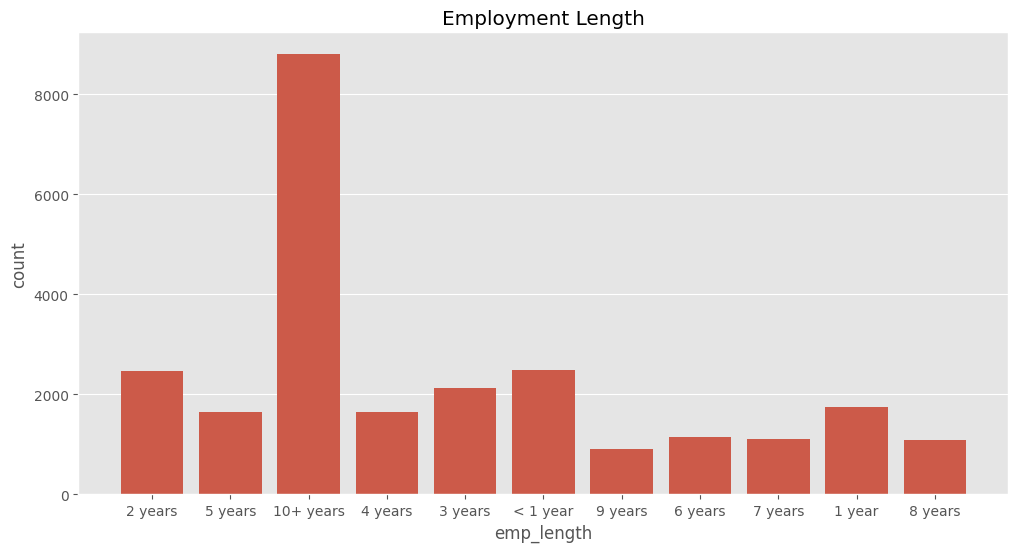

In [76]:
plt.figure(figsize=(12, 6))
sns.countplot(x='emp_length', data=consistent_df)
plt.title('Employment Length')
plt.plot()

In [77]:
mode_emp_length = consistent_df.groupby('emp_title')['emp_length'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

def impute_emp_length(row):
    if pd.isna(row['emp_length']) and pd.notna(row['emp_title']):
        return mode_emp_length[row['emp_title']]
    return row['emp_length']

consistent_df['emp_length'] = consistent_df.apply(impute_emp_length, axis=1)

In [78]:
consistent_df['emp_length'].isnull().sum(), consistent_df['emp_length'].unique()

(0,
 array(['2 years', '5 years', '10+ years', '4 years', '3 years',
        '< 1 year', '9 years', '6 years', '7 years', '1 year', '8 years'],
       dtype=object))

In [79]:
consistent_df['emp_length'].isnull().sum()

0

### Chaning data type of `emp_length` from object to float

Since this column represents a numeric value, it is better to store it as an int rather than an object. This will make analysis on this column easier.

In [80]:
consistent_df['emp_length'].unique()

array(['2 years', '5 years', '10+ years', '4 years', '3 years',
       '< 1 year', '9 years', '6 years', '7 years', '1 year', '8 years'],
      dtype=object)

In [81]:
def convert_emp_length(emp_length):
    if pd.isnull(emp_length):
        return np.nan
    elif emp_length == '10+ years':
        return 10
    elif emp_length == '< 1 year':
        return 0
    else:
        return int(emp_length.split()[0])

In [82]:
consistent_df['emp_length_years'] = consistent_df['emp_length'].apply(convert_emp_length)

In [83]:
consistent_df['emp_length_years'].unique(), consistent_df['emp_length_years'].dtype

(array([ 2,  5, 10,  4,  3,  0,  9,  6,  7,  1,  8], dtype=int64),
 dtype('int64'))

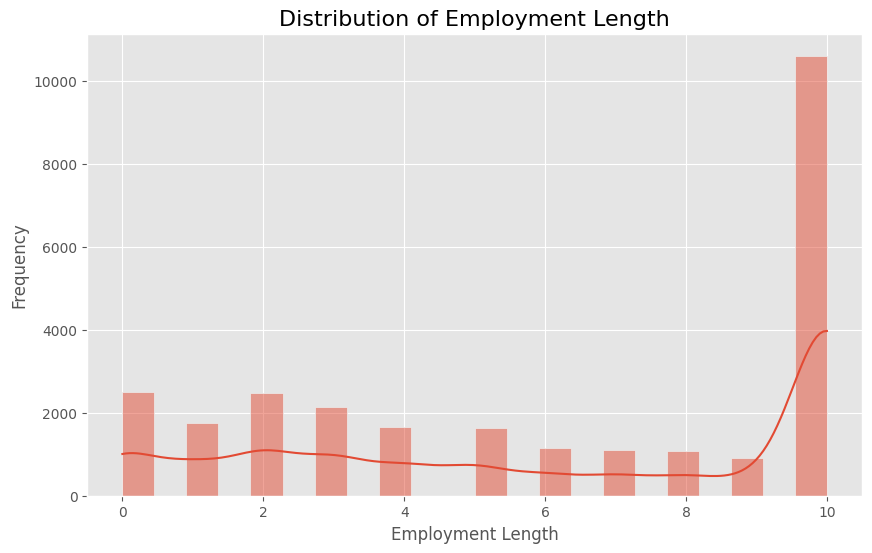

In [84]:
plt.figure(figsize=(10,6))
sns.histplot(consistent_df['emp_length_years'], kde=True)
plt.title('Distribution of Employment Length', fontsize=16)
plt.xlabel('Employment Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

## Observing outliers

In [85]:
consistent_df.columns 

Index(['emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'annual_inc_joint', 'verification_status', 'zip_code', 'addr_state',
       'avg_cur_bal', 'tot_cur_bal', 'loan_id', 'loan_status', 'loan_amount',
       'state', 'funded_amount', 'term', 'int_rate', 'grade', 'issue_date',
       'pymnt_plan', 'type', 'purpose', 'annual_inc_joint_original',
       'emp_length_years'],
      dtype='object')

In [86]:
def plot_all_distributions(df, columns):
    num_columns = len(columns)
    num_rows = (num_columns // 3) + (num_columns % 3 > 0)

    plt.figure(figsize=(20, num_rows * 5))
    
    for i, column in enumerate(columns, 1):
        plt.subplot(num_rows, 3, i)
        if df[column].dtype in ['int64', 'float64']:
            sns.histplot(df[column], kde=True)
            plt.title(f'Distribution of {column}', fontsize=14)
            plt.xlabel(column, fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
        else:
            sns.countplot(x=df[column], order=df[column].value_counts().index)
            plt.title(f'Distribution of {column}', fontsize=14)
            plt.xlabel(column, fontsize=12)
            plt.ylabel('Count', fontsize=12)
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

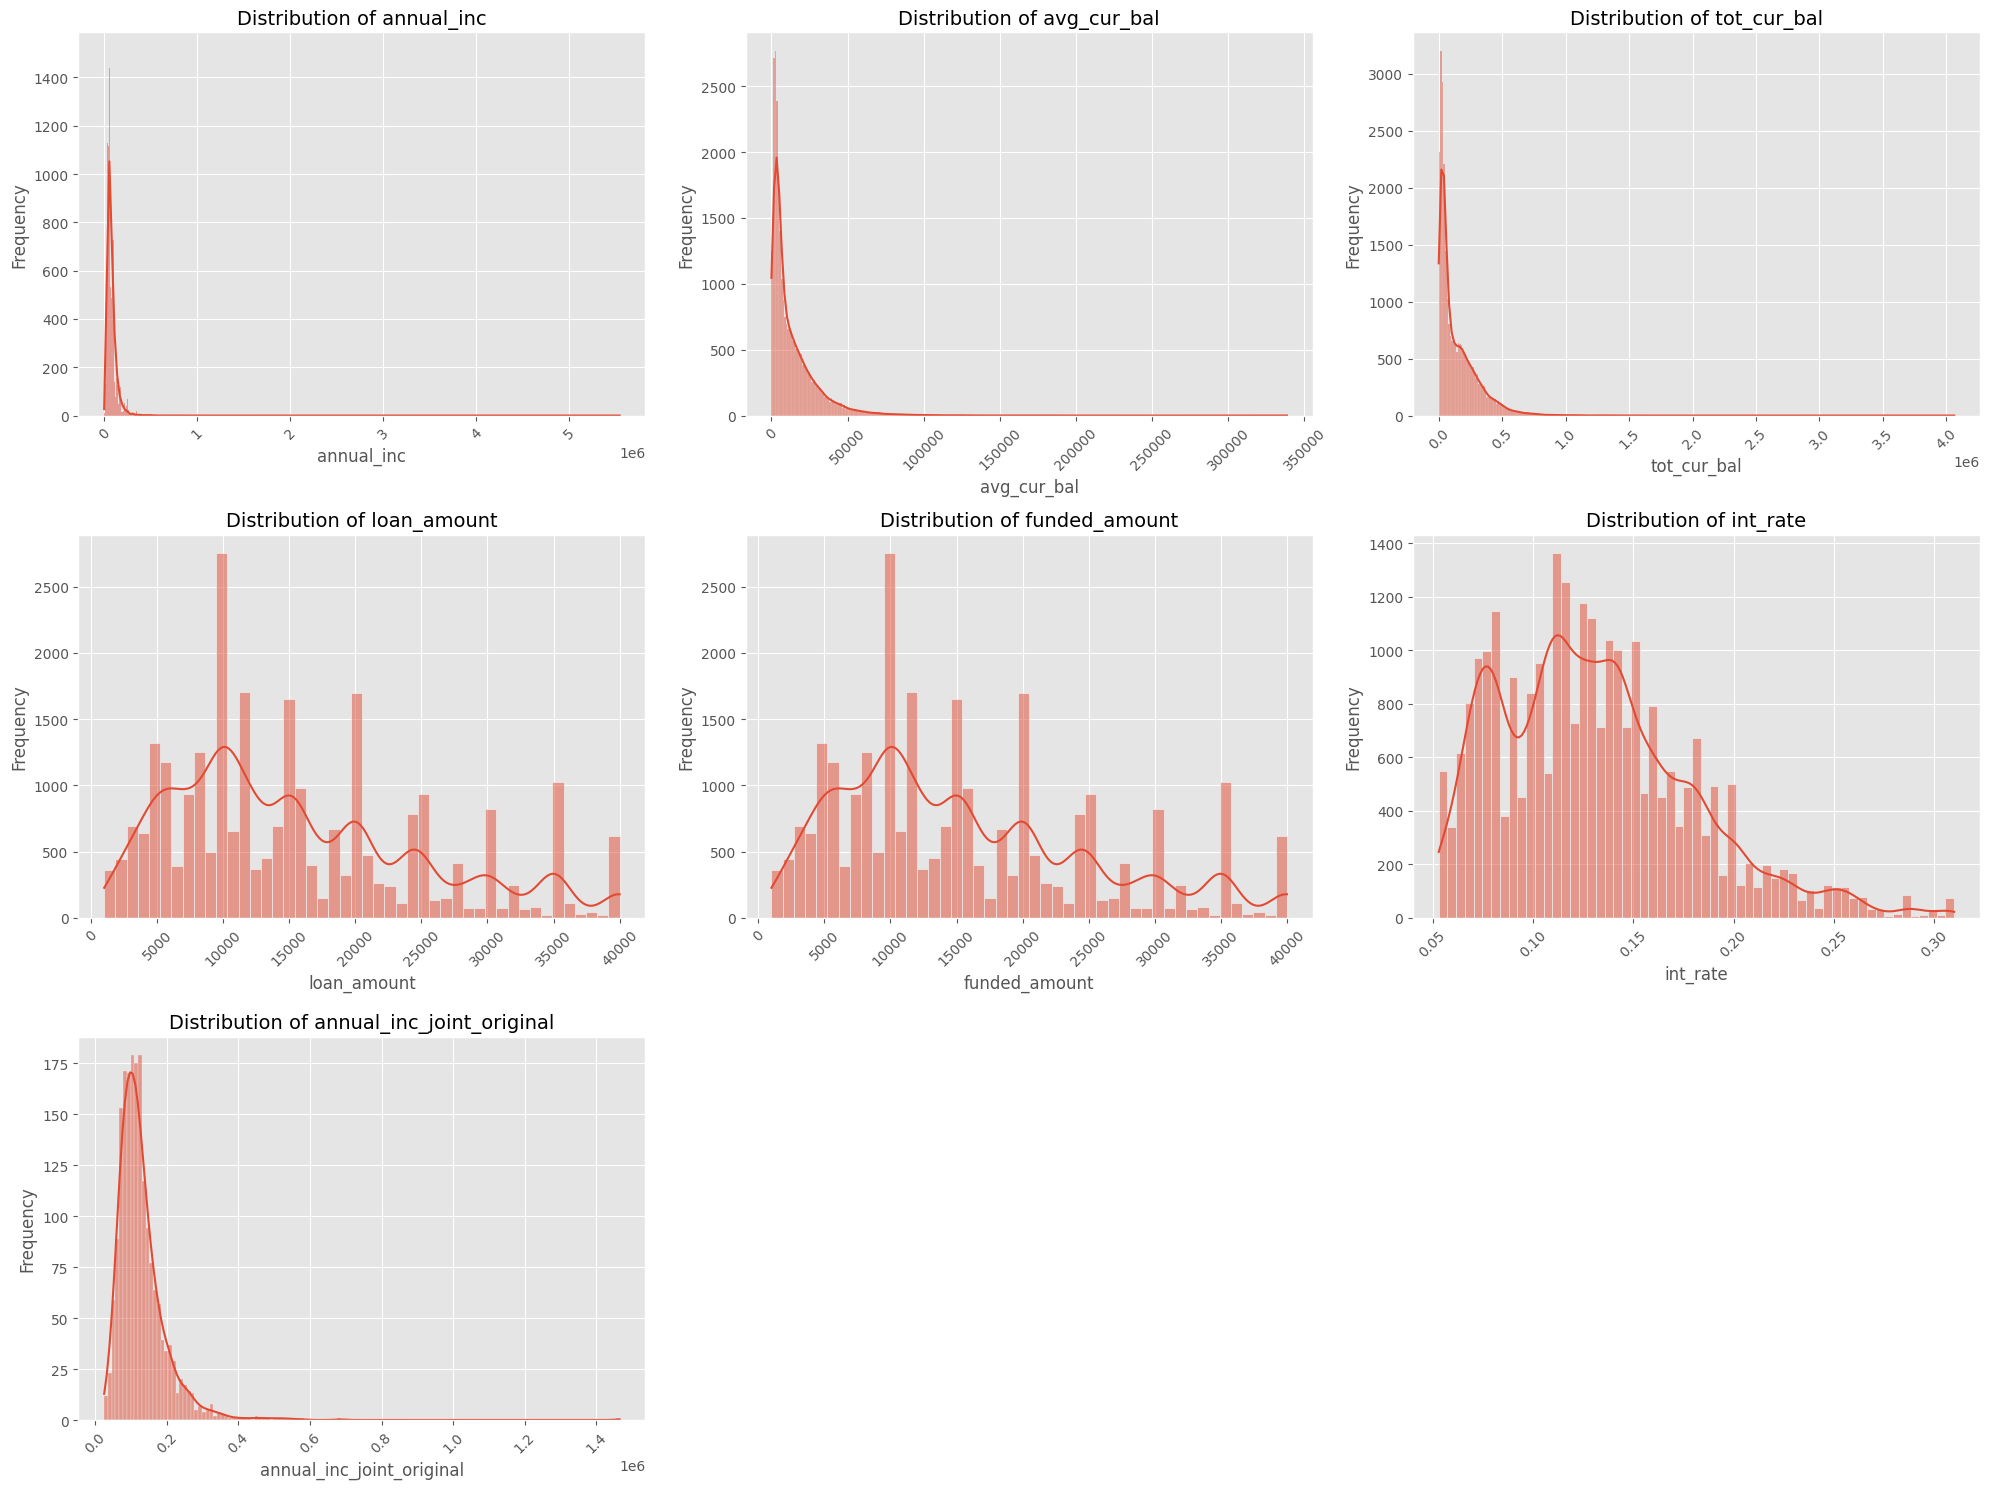

In [87]:
columns_to_plot = ['annual_inc', 'avg_cur_bal', 'tot_cur_bal', 
                    'loan_amount', 'funded_amount',
                    'int_rate', 'annual_inc_joint_original']

plot_all_distributions(consistent_df, columns_to_plot)

In [88]:
def plot_boxplot_for_outliers(df, column_name):
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x=column_name)
    plt.title(f'Box Plot for {column_name}', fontsize=16)
    plt.ylabel(column_name, fontsize=12)
    plt.show()

In [89]:
def find_outliers_iqr(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    return outliers, f'{len(outliers) / len(df) * 100:.3f}%', lower_bound, upper_bound

In [90]:
def find_outliers_zscores(df, column_name, threshold=3):
    z_scores = (df[column_name] - df[column_name].mean()) / df[column_name].std()
    outliers = df[np.abs(z_scores) > threshold]

    return outliers, f'{len(outliers) / len(df) * 100:.3f}%'

In [91]:
def detect_outliers_zscore(df, column, threshold=3):
    z_scores = (df[column] - df[column].mean()) / df[column].std()
    outlier_mask = np.abs(z_scores) > threshold
    
    print(f'Outlier detection for {column}:')
    print(f'Number of outliers detected: {outlier_mask.sum()} ({outlier_mask.sum() / len(df) * 100:.3f}%)')

    return outlier_mask

In [92]:
def remove_outliers_cap(df, column, new_column_name, lower_threshold, upper_threshold):
    df[new_column_name] = np.where(df[column] > upper_threshold, upper_threshold, df[column])
    df[new_column_name] = np.where(df[new_column_name] < lower_threshold, lower_threshold, df[new_column_name])

    return df

In [ ]:
def log_transform_outliers(df, column_name):
    df[column_name] = np.log(df[column_name] + 1)
    return df

In [94]:
def apply_log_transformation(df, column_name):
    plot_boxplot_for_outliers(df, column_name)
    outliers, outliers_percentage, lower_bound, upper_bound = find_outliers_iqr(df, column_name)
    print(f'Outlier percentage: {outliers_percentage}', f'Lower bound: {lower_bound}', f'Upper bound: {upper_bound}')
    df = log_transform_outliers(df, column_name)
    _, outliers_percentage, _ , _ = find_outliers_iqr(df, column_name)
    print('New outlier percentage: ', outliers_percentage)
    plot_boxplot_for_outliers(df, column_name)
    plot_all_distributions(df, [column_name])

In [95]:
consistent_df.columns

Index(['emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'annual_inc_joint', 'verification_status', 'zip_code', 'addr_state',
       'avg_cur_bal', 'tot_cur_bal', 'loan_id', 'loan_status', 'loan_amount',
       'state', 'funded_amount', 'term', 'int_rate', 'grade', 'issue_date',
       'pymnt_plan', 'type', 'purpose', 'annual_inc_joint_original',
       'emp_length_years'],
      dtype='object')

## Checking and handling outliers

Since the data is skewed to the right, we can use either a box plot or the IQR method to find out the outliers. Then we can use log transformation to reduce the number of outliers in the following columns.

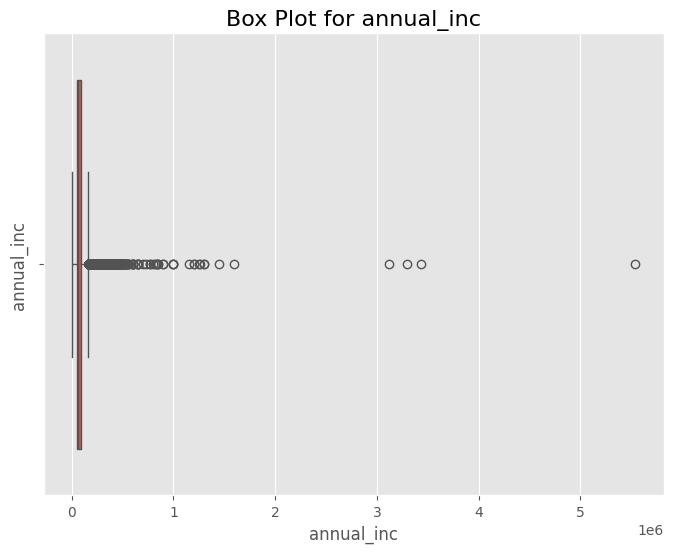

Outlier percentage: 5.124% Lower bound: -23272.5 Upper bound: 165963.5
New outlier percentage:  2.079%


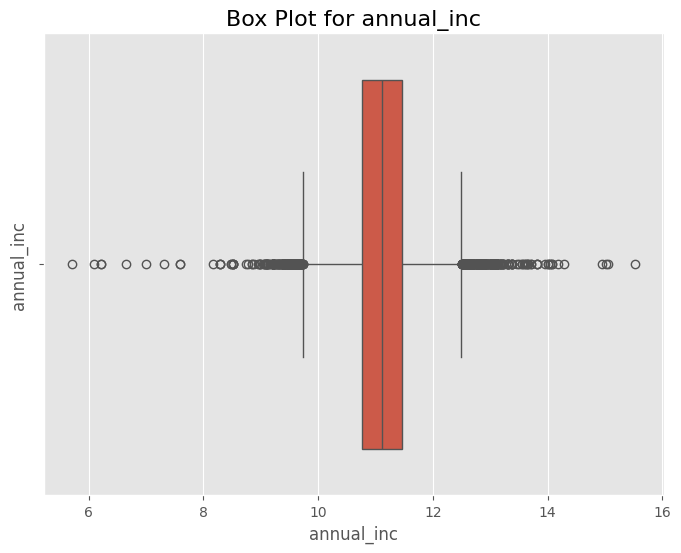

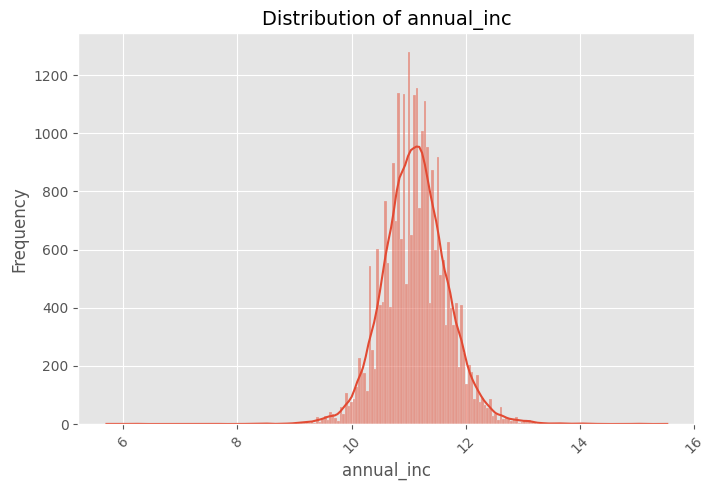

In [96]:
apply_log_transformation(consistent_df, 'annual_inc')

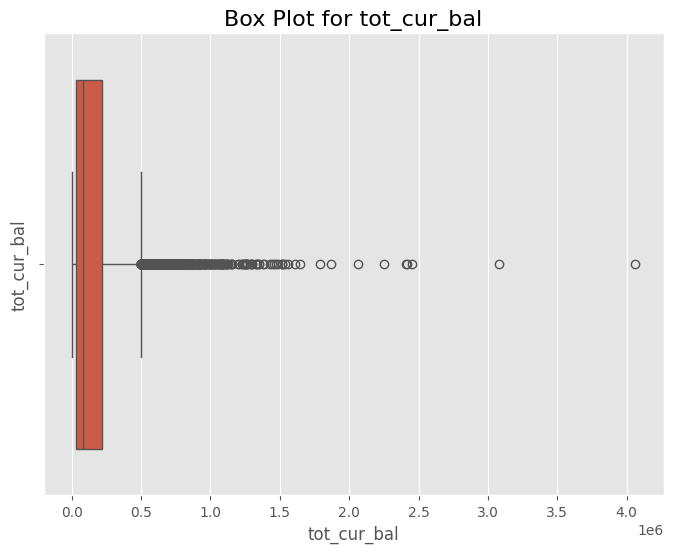

Outlier percentage: 3.681% Lower bound: -250975.0 Upper bound: 497785.0
New outlier percentage:  0.466%


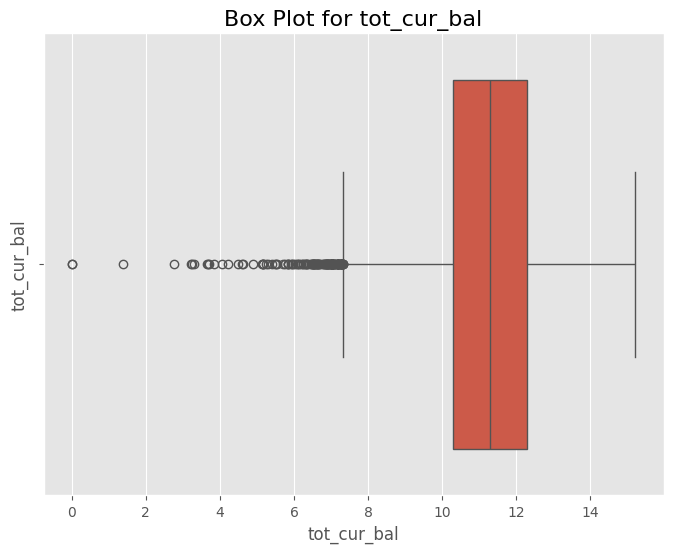

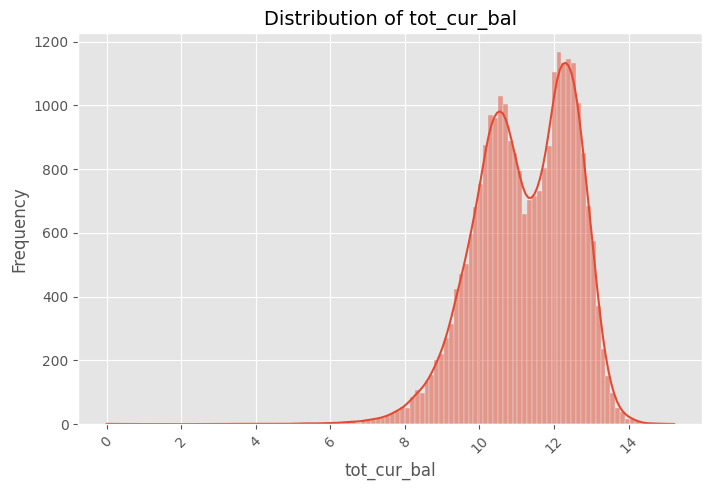

In [97]:
apply_log_transformation(consistent_df, 'tot_cur_bal')

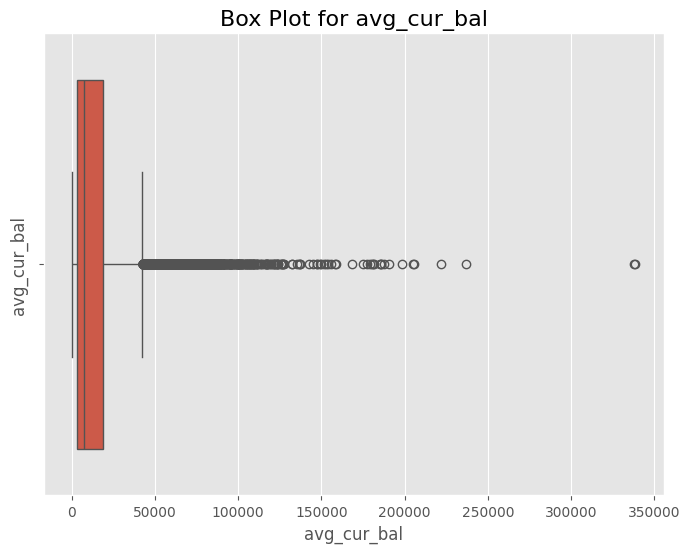

Outlier percentage: 5.683% Lower bound: -20447.0 Upper bound: 42495.0
New outlier percentage:  0.314%


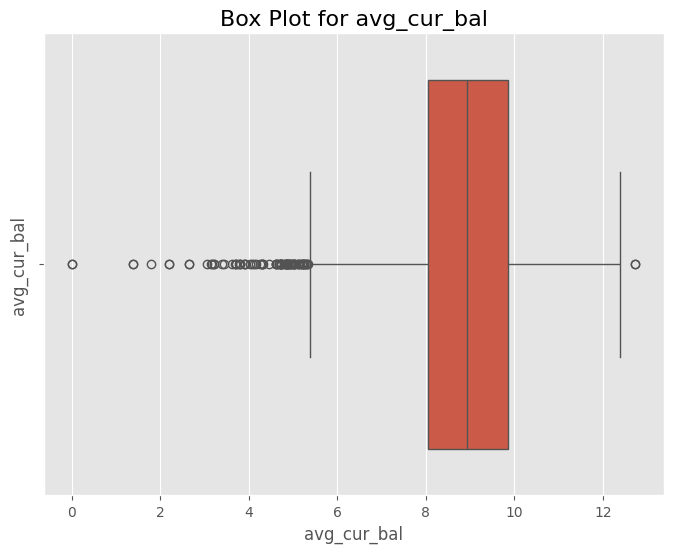

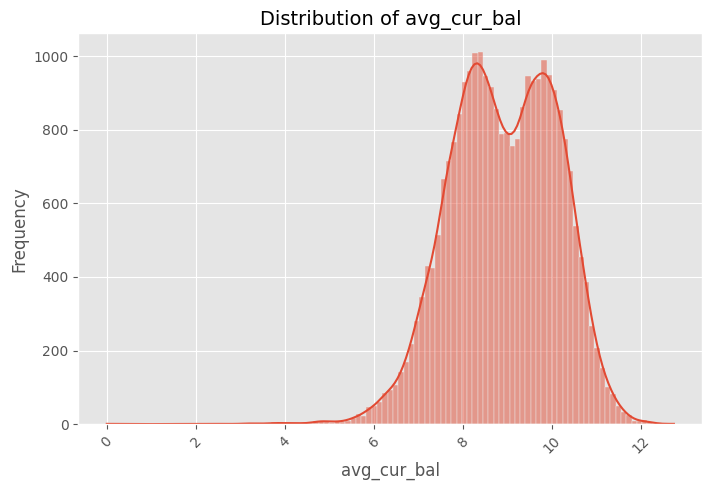

In [98]:
apply_log_transformation(consistent_df, 'avg_cur_bal')

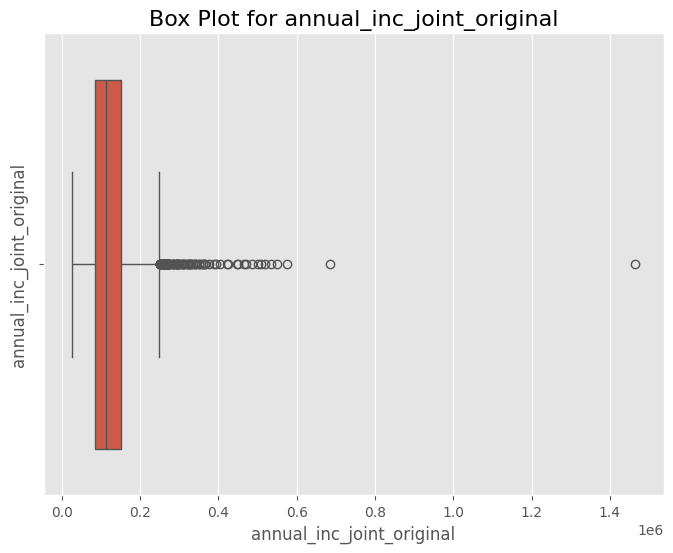

Outlier percentage: 0.374% Lower bound: -11733.2265625 Upper bound: 248888.7109375
New outlier percentage:  0.141%


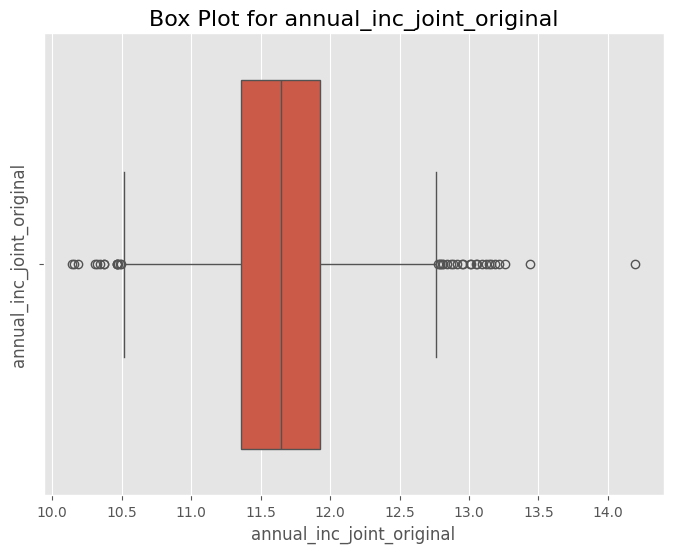

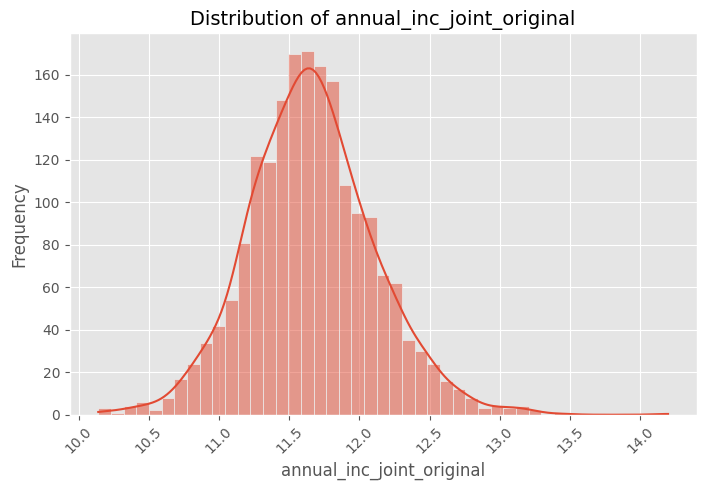

In [99]:
apply_log_transformation(consistent_df, 'annual_inc_joint_original')

# 4 - Data transformation and feature eng.

## 4.1 - Adding Columns

### 4.1.1 Month Number

In [100]:
consistent_df['month_number'] = consistent_df['issue_date'].dt.month

In [101]:
consistent_df[['issue_date','month_number']].sample(10)

,issue_date,month_number
Customer Id,,
YidceDE4XHhiZEBfXHhhNypceGI4XHhiNlx4YmVceGViXHJceDBmblx4ODYmXHhmY1VceDk1XHhjOFx4OWFceGExXHg5N1x4ZWZTXHhmN1xuXHhmYlx4OTVceDgzXHhkMjhceDlhJw==,2017-06-17,6
YidceGE0ZDhdRlx4OGRRO1x4ZDZceGIyXHg4YllceGM3XHhlNFx4YzghXHhjN2xNXHhlNVx4YzRWXHhhZFx4YWFceDhkXHg4MF1ceDlmW1JFXHhkMSc=,2015-02-15,2
YidceGFjQFx4ZDYjXHhhNlx4MGNceDkyXlx4ODlceDg0XHhlN1x4ODlceGIzbVx4MWYlXHhjOFx4ZmVceGI5XHgxMiJfXHhhNlx4YzNceDEzXHhiYmFUXHhjN1x4YzhceDdmICc=,2017-07-17,7
Yid3XHhkNVhqXHhkYlx4YmVceGQxXHg4M0gmXHhmMWBceDBmXHhlZltCJVx4OWJceDBlX1x4ZDFceGI1XHhmMjlceGZlXHhkY1x4OGVceDkxXHgwMFx4MDdceDlkXHg4ZCc=,2014-05-14,5
YiJceDAwXHgxMlxuXHg4ZndceGQ0V1x4ODRceDEyXHgxYVx4MGVaXHhmNVx4YTJ6XHg4NFx4MGNceDEwYFx4MTQnXHg4MVx4OGV6XHg5MFx4ZmZceDgySFx4ZjNceDA1XHg5OFx4MDYi,2018-02-18,2
YiInV1x4ODNnXHhiOCVEXHg4Nlx4YTRceGU2XFwgSlx4ZjcrXHhmM1x4YmMvO0o2T1x4ZjlXXHg4OCZceGJhXHhiNVx4ZWRceDk3R1x4MTIi,2019-04-19,4
YidceGI4YmREXHhkZFx4YWFceGMzXHhiMFx4YTZceDgwXHg4Zlx4ZThceGNlXHhmYVx4ZmVYcVx4YzRceDFkXHhhOVx4Y2NceDk2XHhmYi5ceGZlXHg5NH0vXHhhYUlceGMySyc=,2016-11-16,11
YidcXDJceGUxVVx4ZGNceGJjXHhjOUNTXHhjYlx4ZTJceGYzXHg5Y1x4ODl+Wk5ceGFkXHhiOVx4MGNQXHg4ZFx4MDNTXHg4ZFx0XHg5M25HYmpceDBjJw==,2018-10-18,10
YidceDFkWzAqXHg4MFx4MDZceDAwXHhlNlx4OGMgXHg4ZEpPXHhlMVx4N2ZceGY0XHg4Mlx4ZWVLXHgxZVx4ZjMiXHhlOFx4ZDhceGFhSFx4MDVceDBjd1x4ZmFceGZmXHg5ZCc=,2017-06-17,6


### 4.1.2 Salary Can Cover

In [102]:
inverse_log_annual_inc = np.exp(consistent_df['annual_inc'])
inverse_log_loan_amount = np.exp(consistent_df['loan_amount'])

c:\Users\omar1\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [103]:
consistent_df['salary_can_cover'] = inverse_log_annual_inc >= inverse_log_loan_amount

In [104]:
consistent_df[['annual_inc','loan_amount', 'salary_can_cover']].sample(10)

,annual_inc,loan_amount,salary_can_cover
Customer Id,,,
YidceGNhXHhhYkhceDk0Jlx4ODdceDgzXHg5YzssRm9JRFx4ZDZceGRhXHhkOFx4Y2NhXHhlY1x4ZjBceGE4Tm52O3poXHhhZGVoISc=,11.082158,12225.0,False
YidceGM4XHhjYURceGFkXHhkNlx4MTZceDAxNFx4YmFceGQ0XHhjNzgvXHhkOFx4MDQ7XHhjMFx4YzQuXHhkMlx4ZDQhXHhmZFx4YTNxXHhjYlx4OWZtXHhlMlx4YjA4XHhhYic=,10.859018,10500.0,False
YidceGJkXHg5M2BceDE2XHhkNlx4ODleXHhmOGlceGU0Rlx4ODRceGE1XHhlOFx4MTFceGQ4XHgwZlx4OTEiXHg5MztceGJiXHhmOVx4MDVRXHg4Nlx4ZmZceGJmXHgxYk1ceGI3USc=,10.671673,6000.0,False
YiduXHhkMFx4Y2QiUlx4MGVceGRmJFx4ZjJ9NVx4ODdceDBmXHhmOVx4ZTdOQFVxUVx4ODhceDkwXHhkZFx4MDNceGNjXHhjYVx4ZTNWWFx4MDJceGZhXHhhZSc=,10.819798,10000.0,False
YidceGJjd1tceGUxXHhhZFx4ZTRMXHg3ZkNceDBiXHgwMFx4MDRceDg0XHg4OCxceGMyXHhjOCJqXHgwMHlceGE4XHhhYVx4OTZceDlkW1x4MDRceGRmXHhkZVx4YmNRaCc=,10.881757,10000.0,False
YidcbiBceGY3XHJceDA4XHhlZGtceGIwIENceDliN3dceGJiaVx4OThceGRjXHhiNFx4ZjJceDk0XHhlNVx4YmQvXHhiNFx4OTZbSStceDFmXHhkOEtceDBjJw==,12.100718,35000.0,False
YidceGYwM2FOdXdrU1x4ZjZ1XHgwZmRceGJjXHg5ZkpOXHgxMFx4MDRgfHJceGQwXHhlZFx4MWRceDBlXHhhOFx4ZGVceGViNlx4ZGVceDE1TCc=,9.887409,2400.0,False
YidceGMzXHhhNVx4OTRceGIwXHhiOVx4OGVceGY5XHhhNVx4ZDkiXHg4ZSJceGZkXHhiZC1ceGUzXHgxNTxceDg5XFw3L1x4OTJceDlkZVx4MTdceGY5K1x4ODdceDlhXHhhNVx4MDUn,10.896758,10000.0,False
YidSXHhkM2FUXHhjY1x4YjBceDhmXHhmN1x0XHhkZlx4YzZceGVmXHg4N1x4MGJ7OV5ceDAwXFxceGNmXHhiMlx4YWZceGFkJFx4ZWZceDA3XHhjZFgxXHhmZlx4YzhceDgzJw==,12.301387,40000.0,False


### 4.1.3 Letter Grade

In [105]:
def map_grade(grade):
    if 1 <= grade <= 5:
        return 'A'
    elif 6 <= grade <= 10:
        return 'B'
    elif 11 <= grade <= 15:
        return 'C'
    elif 16 <= grade <= 20:
        return 'D'
    elif 21 <= grade <= 25:
        return 'E'
    elif 26 <= grade <= 30:
        return 'F'
    elif 31 <= grade <= 35:
        return 'G'
    else:
        return 'No Grade'

In [106]:
consistent_df['letter_grade'] = consistent_df['grade'].apply(map_grade).astype('category')
consistent_df['letter_grade'].unique()

['A', 'C', 'F', 'B', 'D', 'E', 'G']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [107]:
consistent_df[['grade', 'letter_grade']], consistent_df['letter_grade'].unique()

(                                                    grade letter_grade
 Customer Id                                                           
 Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWN...      3            A
 Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx...     14            C
 YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDF...     30            F
 YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE...      9            B
 Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWR...      8            B
 ...                                                   ...          ...
 YidceGJlXHhmN1x4YWJceDAyXHhmOFlceDhlTXhceGVhXHg...     16            D
 YidceGJkXHgxY1x4OTNceGEzXHhhY1BceDliXHhkNUVceGM...     16            D
 YidcdFg7XG5ceGE0XHhjNUEmflx4YWZceGMxXHhhM1x4ZmZ...     18            D
 Yic7XHhlYlx4YjRceDlmXHhlNlx4YjVceDk2XHgwN1x0XHh...     21            E
 YidkXHhlOHF8XHhlZlx4YmFceDAwXHgwMiBceGU5K1x4ZWV...     11            C
 
 [27030 rows x 2 columns],
 ['A', 'C', 'F', 'B', 'D', 'E', 'G'

### 4.1.4 Installement per month

In [108]:
def calculate_installement(P, r, n):
    return P * (r * (1 + r) ** n) / ((1 + r) ** n - 1)

In [109]:
consistent_df['monthly_rate'] = consistent_df['int_rate'] / 12
consistent_df['term_int'] = consistent_df['term'].str.extract('(\d+)').astype(int)

In [110]:
consistent_df['installement_per_month'] = consistent_df.apply(lambda row: calculate_installement(row['loan_amount'], row['monthly_rate'], row['term_int']), axis=1)

In [111]:
consistent_df = consistent_df.drop('term_int', axis=1)

Then remove outliers from this column as well using log transformation.

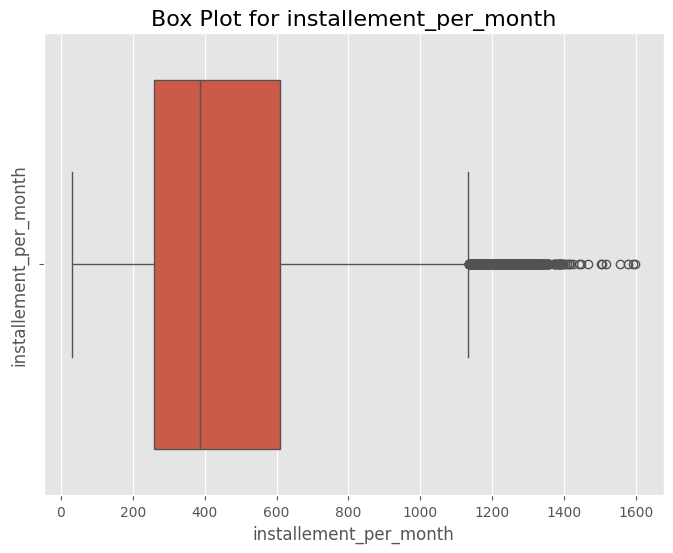

Outlier percentage: 3.030% Lower bound: -265.0055152931385 Upper bound: 1134.0690596084316
New outlier percentage:  1.957%


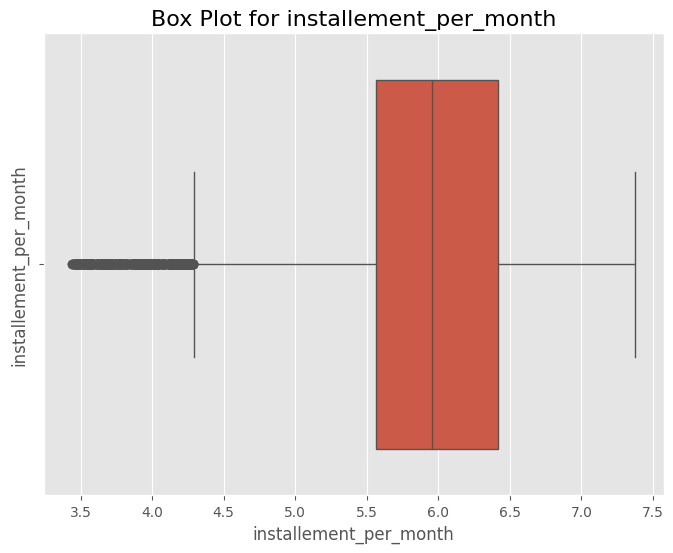

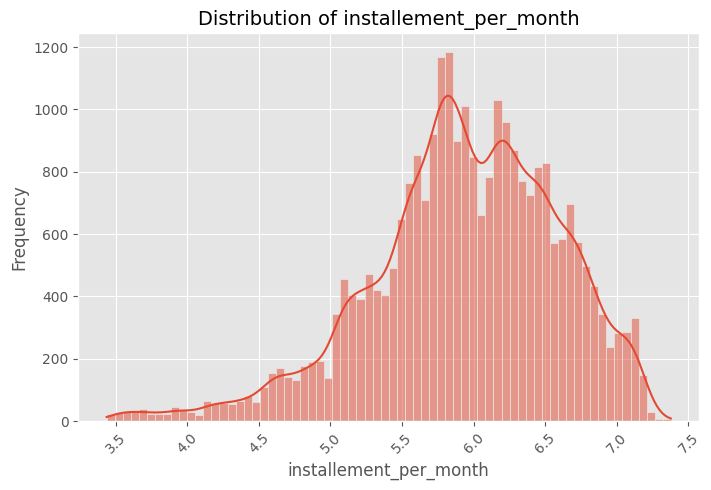

In [112]:
apply_log_transformation(consistent_df, 'installement_per_month')

## 4.2 - Encoding

### Changing data type of `emp_length`

This is already done earlier

Since this column represents a numeric value, it is better to store it as an int rather than an object. This will make analysis on this column easier.

In [113]:
# consistent_df['emp_length'].unique()

In [114]:
# def convert_emp_length(emp_length):
#     if pd.isnull(emp_length):
#         return np.nan
#     elif emp_length == '10+ years':
#         return 10
#     elif emp_length == '< 1 year':
#         return 0
#     else:
#         return int(emp_length.split()[0])

In [115]:
# consistent_df['emp_length_years'] = consistent_df['emp_length'].apply(convert_emp_length)

In [116]:
# consistent_df['emp_length_years'].unique()

### Changing Zipcode from '123xx' object to '123' int

Since all the zip codes in the dataset have 'xx' at the end, which is the delivery area, I decided to remove the 'xx' and store the values as integers to be easier for analysis.

In [117]:
consistent_df['zip_code'].unique()

array(['550xx', '481xx', '447xx', '752xx', '551xx', '484xx', '782xx',
       '928xx', '606xx', '544xx', '300xx', '903xx', '494xx', '706xx',
       '456xx', '770xx', '906xx', '322xx', '471xx', '310xx', '086xx',
       '926xx', '112xx', '421xx', '273xx', '995xx', '853xx', '371xx',
       '023xx', '960xx', '972xx', '641xx', '727xx', '069xx', '553xx',
       '563xx', '387xx', '222xx', '604xx', '443xx', '841xx', '461xx',
       '891xx', '117xx', '010xx', '750xx', '337xx', '123xx', '890xx',
       '973xx', '871xx', '851xx', '287xx', '360xx', '917xx', '349xx',
       '241xx', '189xx', '486xx', '570xx', '451xx', '988xx', '690xx',
       '951xx', '207xx', '208xx', '856xx', '080xx', '263xx', '913xx',
       '070xx', '786xx', '600xx', '209xx', '433xx', '676xx', '774xx',
       '029xx', '936xx', '952xx', '377xx', '113xx', '238xx', '729xx',
       '907xx', '902xx', '612xx', '640xx', '100xx', '605xx', '460xx',
       '140xx', '071xx', '106xx', '760xx', '088xx', '950xx', '114xx',
       '150xx', '457

In [118]:
def convert_zip_code(zip_code):
    if pd.isnull(zip_code):
        return np.nan
    else:
        return int(zip_code[:3])

In [119]:
consistent_df['zip_code_header'] = consistent_df['zip_code'].apply(convert_zip_code)

In [120]:
consistent_df['zip_code_header'].unique()

array([550, 481, 447, 752, 551, 484, 782, 928, 606, 544, 300, 903, 494,
       706, 456, 770, 906, 322, 471, 310,  86, 926, 112, 421, 273, 995,
       853, 371,  23, 960, 972, 641, 727,  69, 553, 563, 387, 222, 604,
       443, 841, 461, 891, 117,  10, 750, 337, 123, 890, 973, 871, 851,
       287, 360, 917, 349, 241, 189, 486, 570, 451, 988, 690, 951, 207,
       208, 856,  80, 263, 913,  70, 786, 600, 209, 433, 676, 774,  29,
       936, 952, 377, 113, 238, 729, 907, 902, 612, 640, 100, 605, 460,
       140,  71, 106, 760,  88, 950, 114, 150, 457, 125, 265, 980,  49,
       920, 788, 145, 275, 327,  87, 658, 331, 719, 975, 359, 294,  77,
       482, 781, 914, 155, 900, 197, 922, 370,  68, 784, 554, 958, 925,
       559, 194, 463, 656, 247, 712, 809, 919,  78, 344, 223, 120, 210,
       953,  20, 532, 785, 959, 341, 334,  67, 665,  76, 221, 548, 754,
       850, 402, 933, 700, 916, 773, 783, 441, 852, 342, 816, 136, 328,
        82, 535, 335, 815, 193, 857, 372, 761,  83,  64, 333, 36

Creating a copy of the dataframe in order to encode some columns and remove the no more required columns.

In [121]:
encoding_df = consistent_df.copy()

Dropping columns that are of no longer interset.

In [122]:
encoding_df = encoding_df.drop(['emp_length', 'annual_inc_joint', 'zip_code'], axis=1)

In [123]:
encoding_df.dtypes

emp_title                            object
home_ownership                       object
annual_inc                          float64
verification_status                  object
addr_state                           object
avg_cur_bal                         float64
tot_cur_bal                         float64
loan_id                               int64
loan_status                          object
loan_amount                         float64
state                                object
funded_amount                       float64
term                                 object
int_rate                            float64
grade                                 int64
issue_date                   datetime64[ns]
pymnt_plan                             bool
type                                 object
purpose                              object
annual_inc_joint_original           float64
emp_length_years                      int64
month_number                          int32
salary_can_cover                

### 1 Hot encoding Home Ownership

In [124]:
encoding_df.dtypes

emp_title                            object
home_ownership                       object
annual_inc                          float64
verification_status                  object
addr_state                           object
avg_cur_bal                         float64
tot_cur_bal                         float64
loan_id                               int64
loan_status                          object
loan_amount                         float64
state                                object
funded_amount                       float64
term                                 object
int_rate                            float64
grade                                 int64
issue_date                   datetime64[ns]
pymnt_plan                             bool
type                                 object
purpose                              object
annual_inc_joint_original           float64
emp_length_years                      int64
month_number                          int32
salary_can_cover                

I will use one hot encoding for the following categorical columns (namely `home_ownership`, `verification_status`, `loan_status`, `term`, `type`) since their unique values are not many and no value is more important than the other, and then drop the columns since they are no longer needed.

In [125]:
def one_hot_encoding(df, column_name):
    new_encoded_df = pd.get_dummies(encoding_df[column_name], prefix=column_name)
    df = pd.concat([df, new_encoded_df], axis=1)
    df = df.drop(column_name, axis=1)
    return df

In [126]:
encoding_df = one_hot_encoding(encoding_df, 'home_ownership')

In [127]:
encoding_df.head()

,emp_title,annual_inc,verification_status,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_status,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original,emp_length_years,month_number,salary_can_cover,letter_grade,monthly_rate,installement_per_month,zip_code_header,home_ownership_ANY,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT
Customer Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,store manager,11.258046,Source Verified,MN,10.833563,12.779448,146317,Current,15000.0,MN,15000.0,36 months,0.0667,3,2018-10-18,False,INDIVIDUAL,debt_consolidation,NaN,2,10,False,A,0.005558,6.135341,550,False,True,False,False
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,mortgage loan officer,11.561725,Source Verified,MI,10.388133,12.585331,218466,Fully Paid,24000.0,MI,24000.0,60 months,0.1299,14,2016-02-16,False,INDIVIDUAL,debt_consolidation,NaN,5,2,False,C,0.010825,6.304359,481,False,True,False,False
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,supervisor,11.258046,Verified,OH,9.349667,12.122213,240070,Charged Off,30000.0,OH,30000.0,60 months,0.2199,30,2015-07-15,False,INDIVIDUAL,debt_consolidation,NaN,2,7,False,F,0.018325,6.720699,447,False,True,False,False
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,teacher,10.985310,Not Verified,TX,8.778172,11.822614,53658,Fully Paid,7000.0,TX,7000.0,36 months,0.1099,9,2015-07-15,False,INDIVIDUAL,debt_consolidation,NaN,10,7,False,B,0.009158,5.438679,752,False,True,False,False
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,electronics repair technician,11.350418,Source Verified,MN,8.708144,10.499793,15383,Current,3600.0,MN,3600.0,36 months,0.1139,8,2016-12-16,False,INDIVIDUAL,major_purchase,NaN,4,12,False,B,0.009492,4.783529,551,False,False,False,True


In [128]:
encoding_df = one_hot_encoding(encoding_df, 'verification_status')

In [129]:
encoding_df.head()

,emp_title,annual_inc,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_status,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original,emp_length_years,month_number,salary_can_cover,letter_grade,monthly_rate,installement_per_month,zip_code_header,home_ownership_ANY,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified
Customer Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,store manager,11.258046,MN,10.833563,12.779448,146317,Current,15000.0,MN,15000.0,36 months,0.0667,3,2018-10-18,False,INDIVIDUAL,debt_consolidation,NaN,2,10,False,A,0.005558,6.135341,550,False,True,False,False,False,True,False
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,mortgage loan officer,11.561725,MI,10.388133,12.585331,218466,Fully Paid,24000.0,MI,24000.0,60 months,0.1299,14,2016-02-16,False,INDIVIDUAL,debt_consolidation,NaN,5,2,False,C,0.010825,6.304359,481,False,True,False,False,False,True,False
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,supervisor,11.258046,OH,9.349667,12.122213,240070,Charged Off,30000.0,OH,30000.0,60 months,0.2199,30,2015-07-15,False,INDIVIDUAL,debt_consolidation,NaN,2,7,False,F,0.018325,6.720699,447,False,True,False,False,False,False,True
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,teacher,10.985310,TX,8.778172,11.822614,53658,Fully Paid,7000.0,TX,7000.0,36 months,0.1099,9,2015-07-15,False,INDIVIDUAL,debt_consolidation,NaN,10,7,False,B,0.009158,5.438679,752,False,True,False,False,True,False,False
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,electronics repair technician,11.350418,MN,8.708144,10.499793,15383,Current,3600.0,MN,3600.0,36 months,0.1139,8,2016-12-16,False,INDIVIDUAL,major_purchase,NaN,4,12,False,B,0.009492,4.783529,551,False,False,False,True,False,True,False


In [130]:
encoding_df = one_hot_encoding(encoding_df, 'loan_status')

In [131]:
encoding_df.head()


,emp_title,annual_inc,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_amount,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original,emp_length_years,month_number,salary_can_cover,letter_grade,monthly_rate,installement_per_month,zip_code_header,home_ownership_ANY,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,loan_status_Charged Off,loan_status_Current,loan_status_Default,loan_status_Fully Paid,loan_status_In Grace Period,loan_status_Late (16-30 days),loan_status_Late (31-120 days)
Customer Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,store manager,11.258046,MN,10.833563,12.779448,146317,15000.0,MN,15000.0,36 months,0.0667,3,2018-10-18,False,INDIVIDUAL,debt_consolidation,NaN,2,10,False,A,0.005558,6.135341,550,False,True,False,False,False,True,False,False,True,False,False,False,False,False
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,mortgage loan officer,11.561725,MI,10.388133,12.585331,218466,24000.0,MI,24000.0,60 months,0.1299,14,2016-02-16,False,INDIVIDUAL,debt_consolidation,NaN,5,2,False,C,0.010825,6.304359,481,False,True,False,False,False,True,False,False,False,False,True,False,False,False
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,supervisor,11.258046,OH,9.349667,12.122213,240070,30000.0,OH,30000.0,60 months,0.2199,30,2015-07-15,False,INDIVIDUAL,debt_consolidation,NaN,2,7,False,F,0.018325,6.720699,447,False,True,False,False,False,False,True,True,False,False,False,False,False,False
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,teacher,10.985310,TX,8.778172,11.822614,53658,7000.0,TX,7000.0,36 months,0.1099,9,2015-07-15,False,INDIVIDUAL,debt_consolidation,NaN,10,7,False,B,0.009158,5.438679,752,False,True,False,False,True,False,False,False,False,False,True,False,False,False
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,electronics repair technician,11.350418,MN,8.708144,10.499793,15383,3600.0,MN,3600.0,36 months,0.1139,8,2016-12-16,False,INDIVIDUAL,major_purchase,NaN,4,12,False,B,0.009492,4.783529,551,False,False,False,True,False,True,False,False,True,False,False,False,False,False


In [132]:
encoding_df = one_hot_encoding(encoding_df, 'term')

In [133]:
encoding_df.head()

,emp_title,annual_inc,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_amount,state,funded_amount,int_rate,grade,issue_date,pymnt_plan,type,purpose,annual_inc_joint_original,emp_length_years,month_number,salary_can_cover,letter_grade,monthly_rate,installement_per_month,zip_code_header,home_ownership_ANY,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,loan_status_Charged Off,loan_status_Current,loan_status_Default,loan_status_Fully Paid,loan_status_In Grace Period,loan_status_Late (16-30 days),loan_status_Late (31-120 days),term_ 36 months,term_ 60 months
Customer Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,store manager,11.258046,MN,10.833563,12.779448,146317,15000.0,MN,15000.0,0.0667,3,2018-10-18,False,INDIVIDUAL,debt_consolidation,NaN,2,10,False,A,0.005558,6.135341,550,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,mortgage loan officer,11.561725,MI,10.388133,12.585331,218466,24000.0,MI,24000.0,0.1299,14,2016-02-16,False,INDIVIDUAL,debt_consolidation,NaN,5,2,False,C,0.010825,6.304359,481,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,supervisor,11.258046,OH,9.349667,12.122213,240070,30000.0,OH,30000.0,0.2199,30,2015-07-15,False,INDIVIDUAL,debt_consolidation,NaN,2,7,False,F,0.018325,6.720699,447,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,True
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,teacher,10.985310,TX,8.778172,11.822614,53658,7000.0,TX,7000.0,0.1099,9,2015-07-15,False,INDIVIDUAL,debt_consolidation,NaN,10,7,False,B,0.009158,5.438679,752,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,electronics repair technician,11.350418,MN,8.708144,10.499793,15383,3600.0,MN,3600.0,0.1139,8,2016-12-16,False,INDIVIDUAL,major_purchase,NaN,4,12,False,B,0.009492,4.783529,551,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False


In [134]:
encoding_df = one_hot_encoding(encoding_df, 'type')

In [135]:
encoding_df.head()

,emp_title,annual_inc,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_amount,state,funded_amount,int_rate,grade,issue_date,pymnt_plan,purpose,annual_inc_joint_original,emp_length_years,month_number,salary_can_cover,letter_grade,monthly_rate,installement_per_month,zip_code_header,home_ownership_ANY,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,loan_status_Charged Off,loan_status_Current,loan_status_Default,loan_status_Fully Paid,loan_status_In Grace Period,loan_status_Late (16-30 days),loan_status_Late (31-120 days),term_ 36 months,term_ 60 months,type_DIRECT_PAY,type_INDIVIDUAL,type_JOINT
Customer Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,store manager,11.258046,MN,10.833563,12.779448,146317,15000.0,MN,15000.0,0.0667,3,2018-10-18,False,debt_consolidation,NaN,2,10,False,A,0.005558,6.135341,550,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,mortgage loan officer,11.561725,MI,10.388133,12.585331,218466,24000.0,MI,24000.0,0.1299,14,2016-02-16,False,debt_consolidation,NaN,5,2,False,C,0.010825,6.304359,481,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,supervisor,11.258046,OH,9.349667,12.122213,240070,30000.0,OH,30000.0,0.2199,30,2015-07-15,False,debt_consolidation,NaN,2,7,False,F,0.018325,6.720699,447,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,True,False
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,teacher,10.985310,TX,8.778172,11.822614,53658,7000.0,TX,7000.0,0.1099,9,2015-07-15,False,debt_consolidation,NaN,10,7,False,B,0.009158,5.438679,752,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,electronics repair technician,11.350418,MN,8.708144,10.499793,15383,3600.0,MN,3600.0,0.1139,8,2016-12-16,False,major_purchase,NaN,4,12,False,B,0.009492,4.783529,551,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False


In [136]:
encoding_df.dtypes

emp_title                                      object
annual_inc                                    float64
addr_state                                     object
avg_cur_bal                                   float64
tot_cur_bal                                   float64
loan_id                                         int64
loan_amount                                   float64
state                                          object
funded_amount                                 float64
int_rate                                      float64
grade                                           int64
issue_date                             datetime64[ns]
pymnt_plan                                       bool
purpose                                        object
annual_inc_joint_original                     float64
emp_length_years                                int64
month_number                                    int32
salary_can_cover                                 bool
letter_grade                

Enconding the following columns (namely `letter_grade`, `state`, and `addr_state`) using label encoding because the values have meaning and some have a higher priority than others

In [137]:
def label_encoding(df, column_name, label_column_name):
    encoder = LabelEncoder()
    df[label_column_name] = encoder.fit_transform(df[column_name])
    return df

In [138]:
encoding_df = label_encoding(encoding_df, 'letter_grade', 'grade_label')
encoding_df[['letter_grade', 'grade_label']].head()

,letter_grade,grade_label
Customer Id,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,A,0
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,C,2
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,F,5
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,B,1
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,B,1


The `state` and `addr_state` will be labelled in lexiographical order.

In [139]:
encoding_df = label_encoding(encoding_df, 'state', 'state_label')
encoding_df[['state', 'state_label']].head()

,state,state_label
Customer Id,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,MN,22
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,MI,21
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,OH,34
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,TX,42
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,MN,22


In [140]:
encoding_df = label_encoding(encoding_df, 'addr_state', 'addr_state_label')
encoding_df[['addr_state', 'addr_state_label']].head()

,addr_state,addr_state_label
Customer Id,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,MN,22
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,MI,21
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,OH,34
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,TX,42
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,MN,22


## 4.3 - Normalization 

In [141]:
encoding_df.head()

,emp_title,annual_inc,addr_state,avg_cur_bal,tot_cur_bal,loan_id,loan_amount,state,funded_amount,int_rate,grade,issue_date,pymnt_plan,purpose,annual_inc_joint_original,emp_length_years,month_number,salary_can_cover,letter_grade,monthly_rate,installement_per_month,zip_code_header,home_ownership_ANY,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,loan_status_Charged Off,loan_status_Current,loan_status_Default,loan_status_Fully Paid,loan_status_In Grace Period,loan_status_Late (16-30 days),loan_status_Late (31-120 days),term_ 36 months,term_ 60 months,type_DIRECT_PAY,type_INDIVIDUAL,type_JOINT,grade_label,state_label,addr_state_label
Customer Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,store manager,11.258046,MN,10.833563,12.779448,146317,15000.0,MN,15000.0,0.0667,3,2018-10-18,False,debt_consolidation,NaN,2,10,False,A,0.005558,6.135341,550,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,0,22,22
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,mortgage loan officer,11.561725,MI,10.388133,12.585331,218466,24000.0,MI,24000.0,0.1299,14,2016-02-16,False,debt_consolidation,NaN,5,2,False,C,0.010825,6.304359,481,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False,2,21,21
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,supervisor,11.258046,OH,9.349667,12.122213,240070,30000.0,OH,30000.0,0.2199,30,2015-07-15,False,debt_consolidation,NaN,2,7,False,F,0.018325,6.720699,447,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,True,False,5,34,34
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,teacher,10.985310,TX,8.778172,11.822614,53658,7000.0,TX,7000.0,0.1099,9,2015-07-15,False,debt_consolidation,NaN,10,7,False,B,0.009158,5.438679,752,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False,1,42,42
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,electronics repair technician,11.350418,MN,8.708144,10.499793,15383,3600.0,MN,3600.0,0.1139,8,2016-12-16,False,major_purchase,NaN,4,12,False,B,0.009492,4.783529,551,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,1,22,22


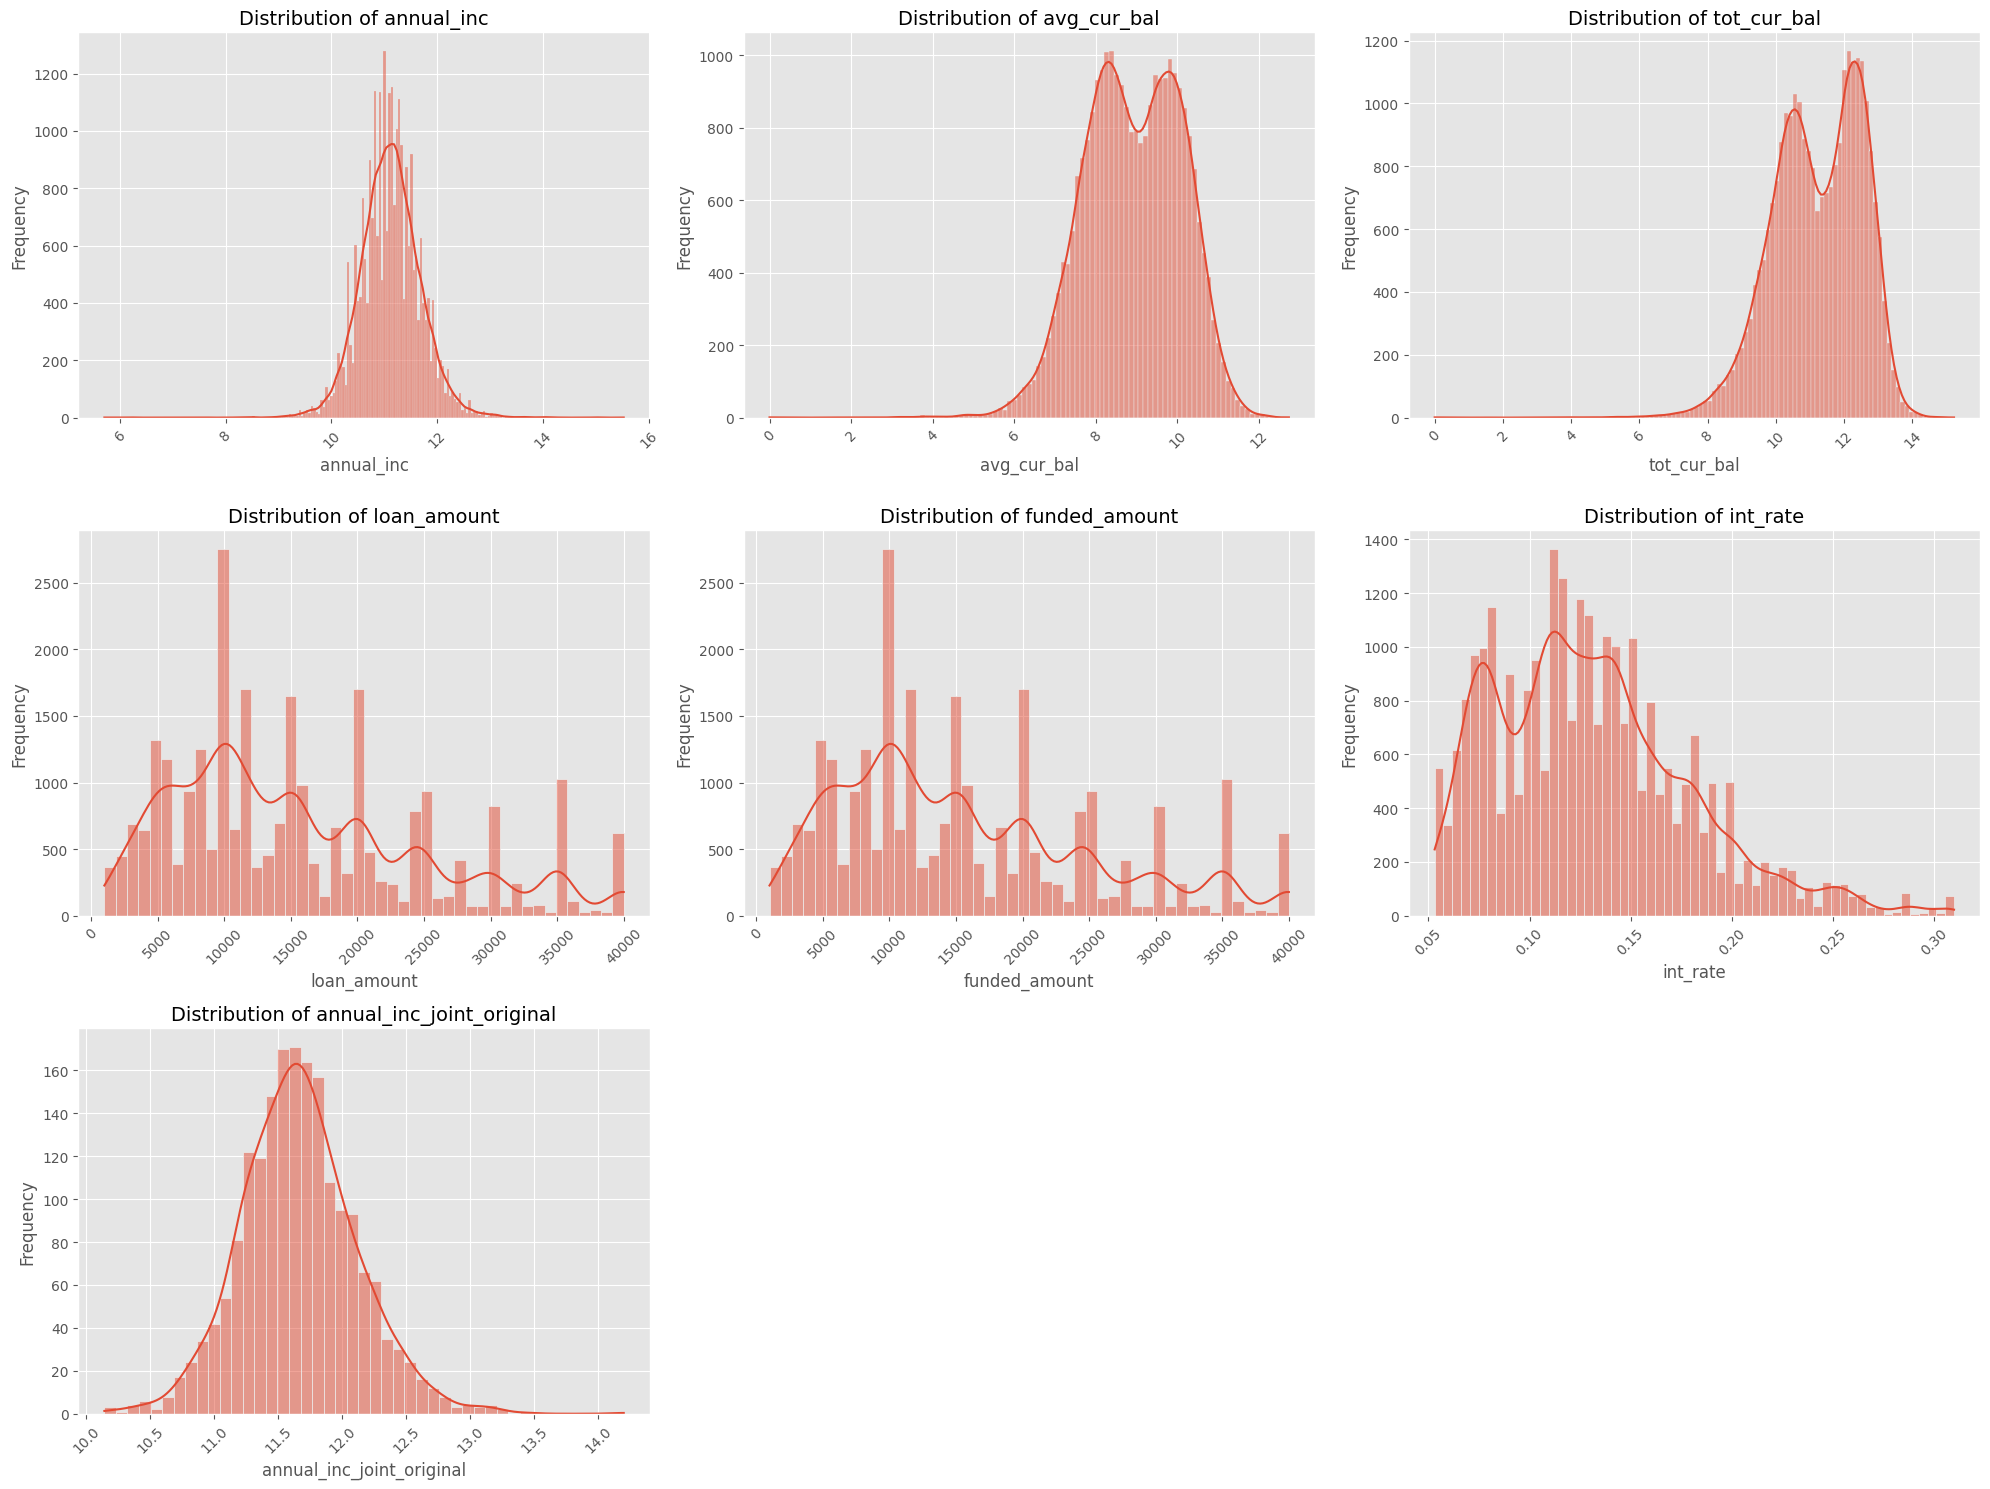

In [142]:
columns_to_plot = ['annual_inc', 'avg_cur_bal', 'tot_cur_bal', 
                    'loan_amount', 'funded_amount',
                    'int_rate', 'annual_inc_joint_original']

plot_all_distributions(encoding_df, columns_to_plot)

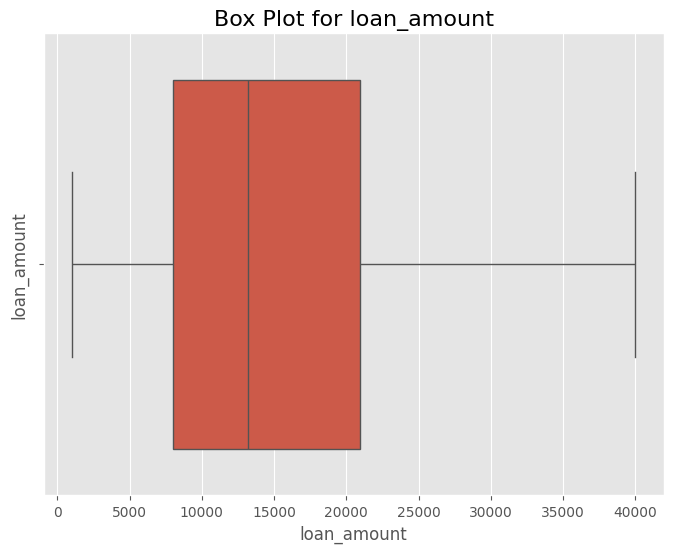

Outlier percentage: 0.000% Lower bound: -11425.0 Upper bound: 40375.0
New outlier percentage:  1.350%


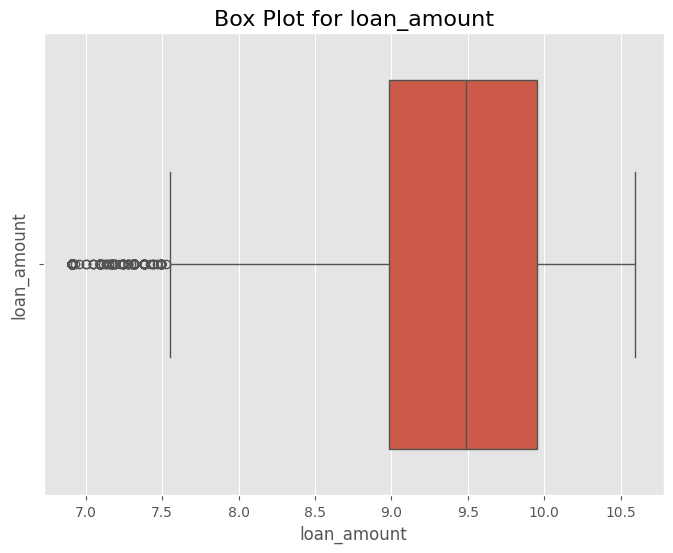

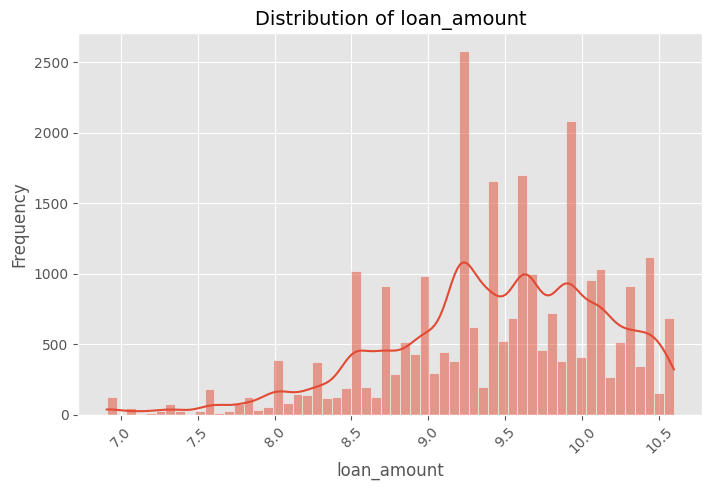

In [143]:
apply_log_transformation(consistent_df, 'loan_amount')

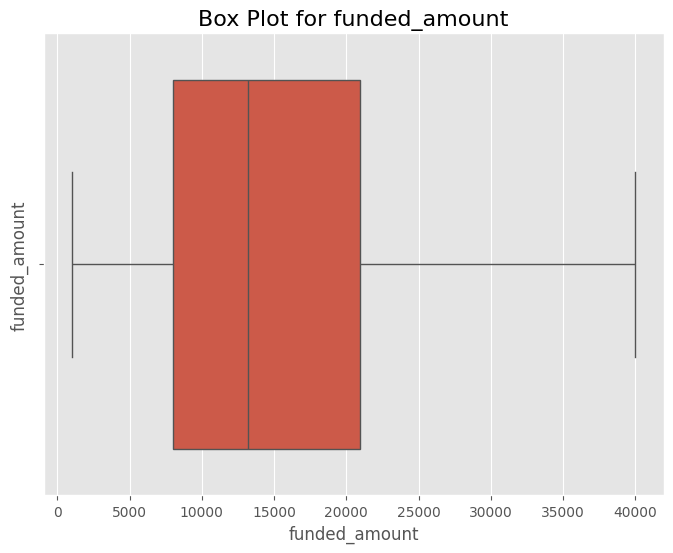

Outlier percentage: 0.000% Lower bound: -11425.0 Upper bound: 40375.0
New outlier percentage:  1.350%


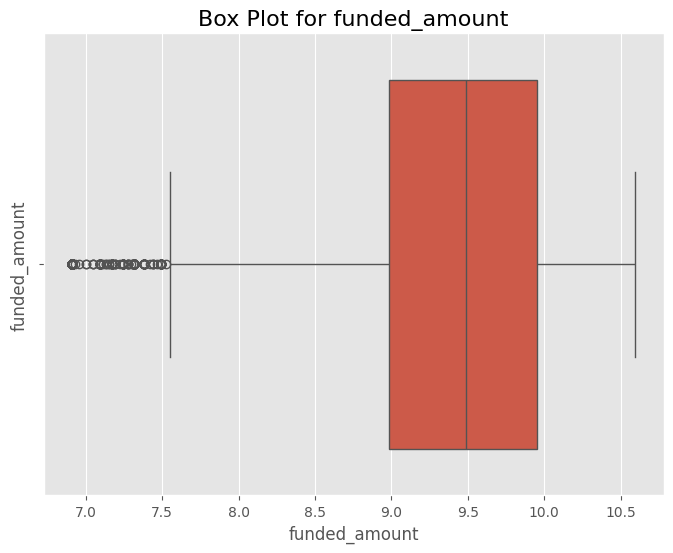

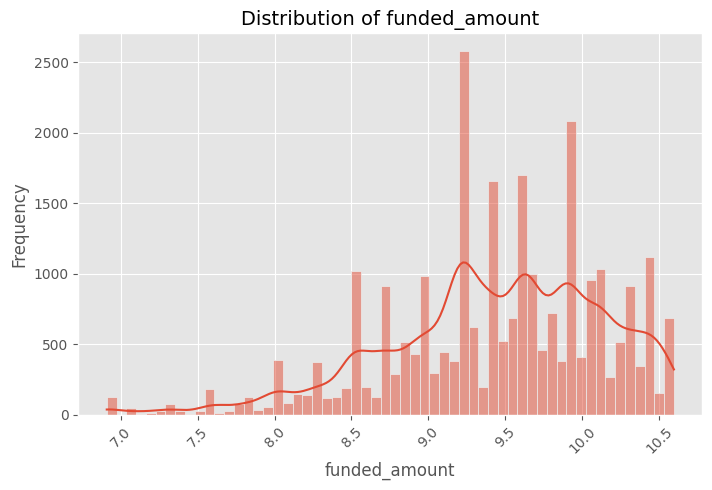

In [144]:
apply_log_transformation(consistent_df, 'funded_amount')


Finally, checking the final columns we are left with

In [145]:
encoding_df.columns

Index(['emp_title', 'annual_inc', 'addr_state', 'avg_cur_bal', 'tot_cur_bal',
       'loan_id', 'loan_amount', 'state', 'funded_amount', 'int_rate', 'grade',
       'issue_date', 'pymnt_plan', 'purpose', 'annual_inc_joint_original',
       'emp_length_years', 'month_number', 'salary_can_cover', 'letter_grade',
       'monthly_rate', 'installement_per_month', 'zip_code_header',
       'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_OWN',
       'home_ownership_RENT', 'verification_status_Not Verified',
       'verification_status_Source Verified', 'verification_status_Verified',
       'loan_status_Charged Off', 'loan_status_Current', 'loan_status_Default',
       'loan_status_Fully Paid', 'loan_status_In Grace Period',
       'loan_status_Late (16-30 days)', 'loan_status_Late (31-120 days)',
       'term_ 36 months', 'term_ 60 months', 'type_DIRECT_PAY',
       'type_INDIVIDUAL', 'type_JOINT', 'grade_label', 'state_label',
       'addr_state_label'],
      dtype='objec

In [146]:
final_df = encoding_df.copy()

In [147]:
final_df.shape, final_df.columns

((27030, 44),
 Index(['emp_title', 'annual_inc', 'addr_state', 'avg_cur_bal', 'tot_cur_bal',
        'loan_id', 'loan_amount', 'state', 'funded_amount', 'int_rate', 'grade',
        'issue_date', 'pymnt_plan', 'purpose', 'annual_inc_joint_original',
        'emp_length_years', 'month_number', 'salary_can_cover', 'letter_grade',
        'monthly_rate', 'installement_per_month', 'zip_code_header',
        'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_OWN',
        'home_ownership_RENT', 'verification_status_Not Verified',
        'verification_status_Source Verified', 'verification_status_Verified',
        'loan_status_Charged Off', 'loan_status_Current', 'loan_status_Default',
        'loan_status_Fully Paid', 'loan_status_In Grace Period',
        'loan_status_Late (16-30 days)', 'loan_status_Late (31-120 days)',
        'term_ 36 months', 'term_ 60 months', 'type_DIRECT_PAY',
        'type_INDIVIDUAL', 'type_JOINT', 'grade_label', 'state_label',
        'addr_state

In [148]:
for column in final_df.select_dtypes(include=['number']).columns:
    min_value = final_df[column].min()
    max_value = final_df[column].max()
    print(f"Column: {column}")
    print(f"Min: {min_value}")
    print(f"Max: {max_value}")
    print("-" * 40)

Column: annual_inc
Min: 5.707110264748875
Max: 15.527707384824557
----------------------------------------
Column: avg_cur_bal
Min: 0.0
Max: 12.73234731585041
----------------------------------------
Column: tot_cur_bal
Min: 0.0
Max: 15.217249780783524
----------------------------------------
Column: loan_id
Min: 12
Max: 270296
----------------------------------------
Column: loan_amount
Min: 1000.0
Max: 40000.0
----------------------------------------
Column: funded_amount
Min: 1000.0
Max: 40000.0
----------------------------------------
Column: int_rate
Min: 0.0531
Max: 0.3099
----------------------------------------
Column: grade
Min: 1
Max: 35
----------------------------------------
Column: annual_inc_joint_original
Min: 10.14033675090645
Max: 14.19736648302693
----------------------------------------
Column: emp_length_years
Min: 0
Max: 10
----------------------------------------
Column: month_number
Min: 1
Max: 12
----------------------------------------
Column: monthly_rate
Min

# 5 - Lookup Table(s)

In [149]:
fintech_df.columns

Index(['emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'annual_inc_joint', 'verification_status', 'zip_code', 'addr_state',
       'avg_cur_bal', 'tot_cur_bal', 'loan_id', 'loan_status', 'loan_amount',
       'state', 'funded_amount', 'term', 'int_rate', 'grade', 'issue_date',
       'pymnt_plan', 'type', 'purpose', 'description'],
      dtype='object')

In [150]:
final_df.columns

Index(['emp_title', 'annual_inc', 'addr_state', 'avg_cur_bal', 'tot_cur_bal',
       'loan_id', 'loan_amount', 'state', 'funded_amount', 'int_rate', 'grade',
       'issue_date', 'pymnt_plan', 'purpose', 'annual_inc_joint_original',
       'emp_length_years', 'month_number', 'salary_can_cover', 'letter_grade',
       'monthly_rate', 'installement_per_month', 'zip_code_header',
       'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_OWN',
       'home_ownership_RENT', 'verification_status_Not Verified',
       'verification_status_Source Verified', 'verification_status_Verified',
       'loan_status_Charged Off', 'loan_status_Current', 'loan_status_Default',
       'loan_status_Fully Paid', 'loan_status_In Grace Period',
       'loan_status_Late (16-30 days)', 'loan_status_Late (31-120 days)',
       'term_ 36 months', 'term_ 60 months', 'type_DIRECT_PAY',
       'type_INDIVIDUAL', 'type_JOINT', 'grade_label', 'state_label',
       'addr_state_label'],
      dtype='objec

In [151]:
mapping = {
    'original': ['emp_length', 'int_rate', 'grade', 'zip_code', 'addr_state', 'annual_inc', 'avg_cur_bal', 'tot_cur_bal', 'total_annual_inc', 'loan_amount', 'funded_amount', 
    'installement_per_month', 'state'],
    'new_name': ['emp_length_years', 'sqrt_int_rate', 'letter_grade', 'zip_code_header', 'addr_state_label', 'normalized_annual_inc', 'normalized_avg_cur_bal', 'normalized_tot_cur_bal'
    ,'normalized_total_annual_inc', 'normalized_loan_amount', 'normalized_funded_amount', 'normalized_installement_per_month', 'state_name']
}

In [152]:
def create_lookup_table(original_df, cleaned_df):
    lookup_list = []

    for original_col in original_df.columns:
        for cleaned_col in cleaned_df.columns:
            if original_col in cleaned_col:

                original_values = original_df[original_col].fillna('missing').astype(str)
                cleaned_values = cleaned_df[cleaned_col].astype(str)
                
                differences = original_values != cleaned_values
                    
                changed_indices = differences[differences].index
                lookup_list.extend([{
                    'Feature': original_col,
                    'Original': original_values.loc[index],
                    'Imputed': cleaned_values.loc[index]
                } for index in changed_indices])
                lookup_table = pd.DataFrame(lookup_list)
    return lookup_table

In [153]:
lookup_table = create_lookup_table(fintech_df, final_df).drop_duplicates()
features_to_keep = ['emp_length', 'addr_state', 'state', 'grade']
cleaned_lookup_table = lookup_table[lookup_table['Feature'].isin(features_to_keep)] 

cleaned_lookup_table.sample(10)

,Feature,Original,Imputed
728416,grade,12,C
728404,grade,16,D
619579,state,HI,11
348826,addr_state,NV,32
728397,grade,11,C
755446,grade,12,2
619106,state,TN,41
728413,grade,20,D
619078,state,MI,21
619104,state,AK,0


In [154]:
def add_entry_to_lookup(lookup_table, new_data):
    
    lookup_table = lookup_table.concat(new_data, ignore_index=True)
    
    return lookup_table

In [155]:
data = {
    'Feature': ['annual_inc_joint', 'home_ownership'],
    'Original': ['Nan', 'OTHER'],
    'Imputed': ['0', 'ANY']
}



cleaned_lookup_table = pd.concat([cleaned_lookup_table, pd.DataFrame(data)], ignore_index=True)

In [156]:
cleaned_lookup_table.to_csv('lookup_table.csv', index=False)

# 6 - Bonus ( Data Integration )

In [157]:
url = "https://www23.statcan.gc.ca/imdb/p3VD.pl?Function=getVD&TVD=53971"
response = requests.get(url)

In [158]:
def fetch_state_data(response):
    soup = BeautifulSoup(response.content, 'html.parser')
    table = soup.find('table')
    
    if not table:
        raise ValueError("No table found in the HTML response.")

    rows = table.find_all('tr')
    state_codes = []
    state_names = []
    
    for row in rows[1:]:
        columns = row.find_all('td')
        if len(columns) == 3:
            state_code = columns[2].text.strip()
            state_name = columns[0].text.strip()
            state_codes.append(state_code)
            state_names.append(state_name)

    return pd.DataFrame({'state_code': state_codes, 'state_name': state_names})

In [159]:
def map_state_names(final_df, state_df):
    state_dict = dict(zip(state_df['state_code'], state_df['state_name']))
    final_df['state_name'] = final_df['state'].map(state_dict)

In [160]:
def get_state_names(response, final_df):
    if response.status_code == 200:
        state_df = fetch_state_data(response)
        print(state_df.head())
        
        map_state_names(final_df, state_df)
    else:
        print(f"Failed to retrieve data. Status code: {response.status_code}")

In [161]:
response = requests.get(url)
get_state_names(response, final_df)
final_df[['state', 'state_name']].head()

  state_code  state_name
0         AL     Alabama
1         AK      Alaska
2         AZ     Arizona
3         AR    Arkansas
4         CA  California


,state,state_name
Customer Id,,
Yid6XHg5Y1x4YWRceDhkXHgwZVx4ZDhceGFlXHg5Y1x4OWNceGZib1gtRi5ceDg1XHhjNTtkM1x4YTNGXHg5Mlx4YjdceGIzXHgxZVx4MDFceDliXHhiNlx4ZGZkXFwn,MN,Minnesota
Yid9XHg4Ylx4ODdceGZlUVx4MWFcXFx4ZjZceDg0XHhhNlx4YzdmXHJcblx4YjFceGNmXHhjMVx4ODhcclx4ODZceGJkblx4ZWRcblx4ZTdceGE3XHhkNFx4MDR7XHhiYX1IJw==,MI,Michigan
YidceDBmXHhiY05ceGY4V1x4OTBceDgxXHhlOFx4ODBceDFmXHhhNFx4OWI3XHgxOVx4YjhceGU1XHg4NFx4OTdNR1x4YmVUalx4ZTdceGU3XHhjMDtceGZlRlx4ODlceDhkRCc=,OH,Ohio
YidceGI3XHhlMFx4MWU1XHhhZVx4YjVceGE0WVx4ZjJceDE0XHg4ZVx4OWY0XHhiODI2XHgxOURceGRjXHgwMFx4OTAqXHhlZUhceDlmXHhkM2pceGEwcFhceGFjZSc=,TX,Texas
Yidxb3l1XHhlMUZceGQ2XHg4YVx4YWJceDE0XHhkNlx4ZWRceGZlXHhhMTpceDljXHhlMVx4MTcuXHg4Nk1ceDg1P0VceGExXHhkNFx4OGJceDE5MFx4YzlceGQ5XHgxMic=,MN,Minnesota


# 7- Exporting the dataframe to a csv file or parquet

In [162]:
final_df.to_csv('cleaned_fintech_df.csv')

In [163]:
# final_df.to_parquet('cleaned_fintech_df.parquet')